In [147]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense,LSTM, Dropout,Input, Concatenate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta



# Este dataframe contiene la cantidad Viajes realizados aperturados por Estacion, por linea , por hora y por dia..

**Los datos corresponden a una base unificada por estaciones, y lo grabaron bajo el año 2020**
- Cabe aclarar que por falta de informacion sobre este dataframe, estos datos los tomo a modo de ejemplo para poder realizar practicas de visualizacion, analisis y predicciones. A mi criterio no tienen nada que ver con lo ocurrido en el año 2020. 

In [148]:
#CARGA DE DATOS

df=pd.read_csv("BaseUnificadaEstaciones.csv")


**EXPLORACION Y LIMPIEZA DE LOS DATOS**

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822363 entries, 0 to 822362
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   FECHA     822363 non-null  object
 1   ESTACION  822363 non-null  object
 2   LINEA     822363 non-null  object
 3   DESDE     822363 non-null  object
 4   HORA      822363 non-null  int64 
 5   CANTIDAD  822363 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 37.6+ MB


In [150]:
df.shape

(822363, 6)

In [151]:
df.describe()

,HORA,CANTIDAD
count,822363.000000,822363.000000
mean,13.368358,31.994799
std,4.548663,76.414429
min,0.000000,1.000000
25%,9.000000,5.000000
50%,13.000000,12.000000
75%,17.000000,29.000000
max,23.000000,3827.000000


In [152]:
df.dtypes


FECHA       object
ESTACION    object
LINEA       object
DESDE       object
HORA         int64
CANTIDAD     int64
dtype: object

In [153]:
df.columns

Index(['FECHA', 'ESTACION', 'LINEA', 'DESDE', 'HORA', 'CANTIDAD'], dtype='object')

In [154]:
df.isnull().sum()

FECHA       0
ESTACION    0
LINEA       0
DESDE       0
HORA        0
CANTIDAD    0
dtype: int64

In [155]:
print(df.isna().sum().sum())


0


In [156]:
df.duplicated().sum()

0

In [157]:
df.sample(5)

,FECHA,ESTACION,LINEA,DESDE,HORA,CANTIDAD
108164,3/18/2020,Facultad Derecho,H,19:15,19,24
89025,3/15/2020,Carlos Gardel,B,20:00,20,129
684443,10/5/2020,Plaza Italia,D,15:00,15,13
14551,3/3/2020,Independencia,C,18:30,18,125
180683,4/16/2020,Correo Central,E,8:30,8,2


In [158]:
df.tail(30)

,FECHA,ESTACION,LINEA,DESDE,HORA,CANTIDAD
822333,11/19/2020,Santa Fe,H,14:15,14,78
822334,11/19/2020,Santa Fe,H,14:30,14,65
822335,11/19/2020,Santa Fe,H,14:45,14,51
822336,11/19/2020,Santa Fe,H,15:00,15,79
822337,11/19/2020,Santa Fe,H,15:15,15,75
822338,11/19/2020,Santa Fe,H,15:30,15,52
822339,11/19/2020,Santa Fe,H,15:45,15,62
822340,11/19/2020,Santa Fe,H,16:00,16,69
822341,11/19/2020,Santa Fe,H,16:15,16,60
822342,11/19/2020,Santa Fe,H,16:30,16,51


In [159]:
#VISUALIZO TODAS LAS ESTACIONES.

estaciones = df['ESTACION'].unique()
print(estaciones)

['Acoyte' 'Alberti' 'Carabobo' 'Castro Barros' 'Congreso' 'Flores' 'Lima'
 'Loria' 'Pasco' 'Peru' 'Piedras' 'Plaza Miserere' 'Primera Junta' 'Puan'
 'Rio de Janeiro' 'Saenz Peña' 'San Pedrito' 'Angel Gallardo' 'Callao'
 'Carlos Gardel' 'Carlos Pellegrini' 'Dorrego' 'Echeverria'
 'Federico Lacroze' 'Florida' 'Leandro N. Alem' 'Los Incas' 'Malabia'
 'Medrano' 'Pasteur' 'Pueyrredon' 'Rosas' 'Tronador' 'Uruguay'
 'Avenida de Mayo' 'Constitucion' 'Diagonal Norte' 'General San Martin'
 'Independencia' 'Lavalle' 'Mariano Moreno' 'Retiro' 'San Juan'
 '9 de julio' 'Aguero' 'Bulnes' 'Callao.' 'Catedral' 'Congreso de Tucuman'
 'Facultad de Medicina' 'Jose Hernandez' 'Juramento' 'Ministro Carranza'
 'Olleros' 'Palermo' 'Plaza Italia' 'Pueyrredon.' 'Scalabrini Ortiz'
 'Tribunales' 'Avenida La Plata' 'Boedo' 'Bolivar' 'Catalinas'
 'Correo Central' 'Emilio Mitre' 'Entre Rios' 'General Belgrano'
 'Independencia.' 'Jose Maria Moreno' 'Jujuy' 'Medalla Milagrosa'
 'Pichincha' 'Pza. de los Virreyes' 'Reti

In [160]:
#VISUALIZACION DE LAS LINEAS.

lineas = df['LINEA'].unique()
print(lineas)

['A' 'B' 'C' 'D' 'E' 'H' 'D              ' 'A              '
 'B              ' 'C              ' 'E              ' 'H              ']


El siguiente código elimina los espacios en blanco al principio y al final de los nombres de las líneas en el DataFrame `df`.

In [161]:
#MODIFICACION DE LOS NOMBRES DE LAS LINEAS

df['LINEA'] = df['LINEA'].str.strip()
lineas = df['LINEA'].unique()
print(lineas)

['A' 'B' 'C' 'D' 'E' 'H']


## ANALISIS DE DATOS

- El siguiente codigo, genera un ranking visual, combinando análisis estadístico y visualización.

- **Ranking x líneas**
- **Top 10 Horas Pico**
- **Top 10 Estaciones con mas pasajeros**
- **Top 10 Estaciones con mas pasajeros**

	
**Visualización con gráfico de torta:**

- Se crean gráficos de torta (pie chart) para representar la distribución de cada una de las variables.


- Este análisis permite identificar de forma clara cuáles son las líneas más utilizadas, horas pico, estaciones mas utilizadas y demas, información útil para planificación de servicios, mantenimiento o estrategias de accesibilidad. 

Rankng LINEAS con mas pasajeros
LINEA
B    6405418
D    5956657
A    4678590
C    4467032
H    2916603
E    1887039
Name: CANTIDAD, dtype: int64


Text(0.5, 1.0, 'Rankng LINEAS con mas pasajeros')

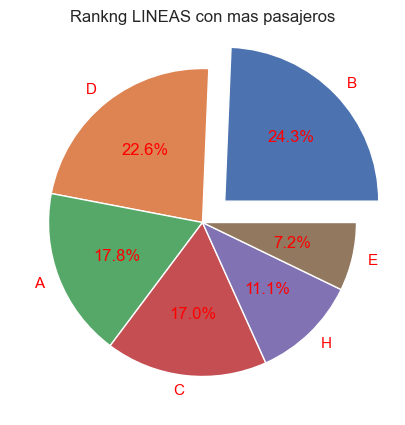

In [162]:
#GENERO UN RANKING DE LAS LINEAS CON MAS PASAJEROS.

lineapass=df.groupby('LINEA')['CANTIDAD'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('Rankng LINEAS con mas pasajeros')
print(lineapass)

plt.figure(figsize=(10,5))
explosion = [0.2 if i==0 else 0 for i in range(len(lineapass))]
plt.pie(lineapass,labels=lineapass.index,autopct='%1.1f%%',startangle=0,explode=explosion , textprops={'color':"red"})
plt.title('Rankng LINEAS con mas pasajeros')

Top 10 Hora Pico
HORA
17    2284702
8     2283271
18    2078516
16    1969571
9     1946911
7     1825235
13    1793791
15    1743104
14    1723481
12    1690113
Name: CANTIDAD, dtype: int64


Text(0.5, 1.0, 'Top 10 Hora Pico')

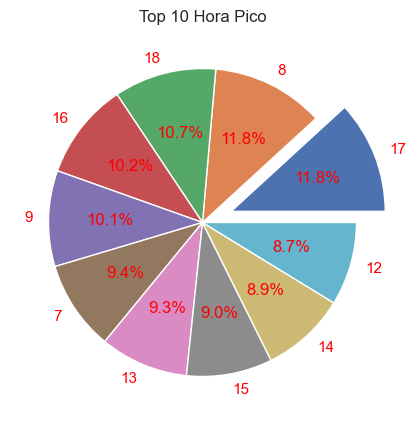

In [163]:
#GENERO UN RANKING DE LAS HORAS PICO CON MAS PASAJEROS.

horapico=df.groupby('HORA')['CANTIDAD'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('Top 10 Hora Pico')
print(horapico)

plt.figure(figsize=(10,5))
explosion = [0.2 if i==0 else 0 for i in range(len(horapico))]
plt.pie(horapico,labels=horapico.index,autopct='%1.1f%%',startangle=0,explode=explosion , textprops={'color':"red"})
plt.title('Top 10 Hora Pico')

Top 10 Estaciones con mas pasajeros
ESTACION
Constitucion           2568335
Retiro                 1066460
Federico Lacroze        910059
Rosas                   856360
Congreso de Tucuman     854368
San Pedrito             821131
Carlos Pellegrini       696534
Peru                    610868
Leandro N. Alem         607614
Catedral                603787
Name: CANTIDAD, dtype: int64


Text(0.5, 1.0, 'Top 10 Estaciones con mas pasajeros')

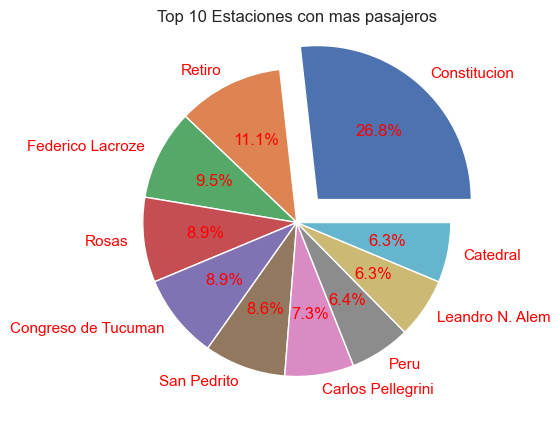

In [164]:
#GENERO UN RANKING DE LAS ESTACIONES CON MAS PASAJEROS.

pass_x_est=df.groupby('ESTACION')['CANTIDAD'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('Top 10 Estaciones con mas pasajeros')
print(pass_x_est)

plt.figure(figsize=(10,5))
explosion = [0.2 if i==0 else 0 for i in range(len(pass_x_est))]
plt.pie(pass_x_est,labels=pass_x_est.index,autopct='%1.1f%%', startangle=0,explode=explosion ,textprops={'color':"red"})
plt.title('Top 10 Estaciones con mas pasajeros')

df.shape



In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822363 entries, 0 to 822362
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   FECHA     822363 non-null  object
 1   ESTACION  822363 non-null  object
 2   LINEA     822363 non-null  object
 3   DESDE     822363 non-null  object
 4   HORA      822363 non-null  int64 
 5   CANTIDAD  822363 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 37.6+ MB


In [166]:
# CONVIERTO FECHA a formato datetime para poder analizar.

df['FECHA'] = pd.to_datetime(df['FECHA'],dayfirst=False)


df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822363 entries, 0 to 822362
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   FECHA     822363 non-null  datetime64[ns]
 1   ESTACION  822363 non-null  object        
 2   LINEA     822363 non-null  object        
 3   DESDE     822363 non-null  object        
 4   HORA      822363 non-null  int64         
 5   CANTIDAD  822363 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 37.6+ MB


In [167]:
df.columns

Index(['FECHA', 'ESTACION', 'LINEA', 'DESDE', 'HORA', 'CANTIDAD'], dtype='object')

**- El siguiente codigo, se generan relaciones visuales entre distintas variables, combinando análisis estadístico y visualización grasfica.**

- **Relacion entre Cantidad Total de Pasajeros por Línea**
- **Relacion entre LINEA & CANTIDAD DE PASAJEROS**
- **Relacion entre Cantidad de Pasajeros por Estación, diferenciados por Línea**
- **Relacion entre HORA & CANTIDAD DE PASAJEROS de TODAS las LINEAS**
- **Relacion entre HORA & CANTIDAD DE PASAJEROS en cada una de las LINEAS**
- **Relacion entre ESTACION & CANTIDAD DE PASAJEROS en cada una de las LINEAS**
- **Relacion entre Cantidad de Pasajeros segun Hora del dia en cada una de las LINEAS**
- **Relacion entre Cantidad de Pasajeros segun Estacion en cada una de las LINEAS**
- **Correlación entre la HORA y la CANTIDAD de Pasajeros en cada una de las LINEAS**
- **Relación entre la HORA y la CANTIDAD de Pasajeros en cada una de las LINEAS**

Relación entre la HORA y la CANTIDAD de Pasajeros por Línea



/var/folders/mc/x95ytzzn5z35gdz502qgy2f80000gn/T/ipykernel_29353/1531050584.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_lineas, x='LINEA', y='CANTIDAD', palette='Blues_d')


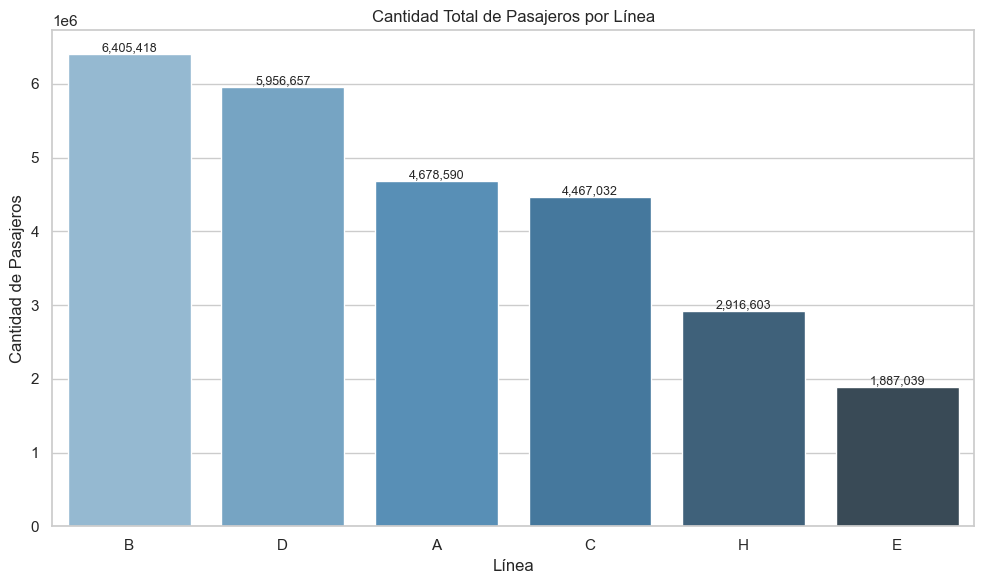

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

# Agrupo por línea y sumo la cantidad de pasajeros
df_lineas = df.groupby('LINEA')['CANTIDAD'].sum().reset_index().sort_values(by='CANTIDAD', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(data=df_lineas, x='LINEA', y='CANTIDAD', palette='Blues_d')
plt.title('Cantidad Total de Pasajeros por Línea')
plt.xlabel('Línea')
plt.ylabel('Cantidad de Pasajeros')

# Total valores en las barras
for i, val in enumerate(df_lineas['CANTIDAD']):
    plt.text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

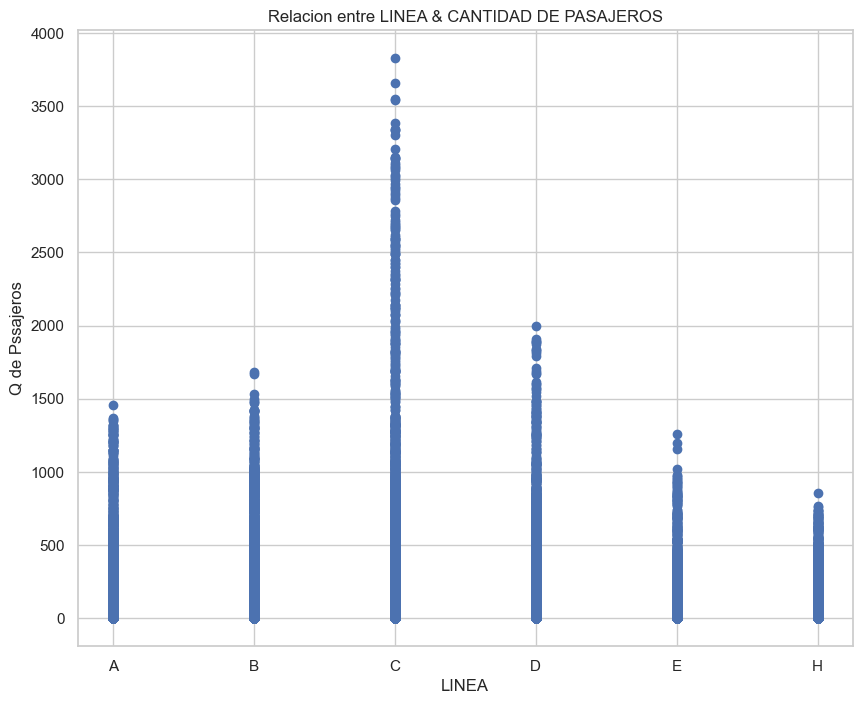

In [169]:
#GRAFICO PARA PODER VISUALIZAR LA CANTIDAD DE PASAJEROS POR LINEA.

plt.figure(figsize=(10,8))
plt.scatter(df['LINEA'], df['CANTIDAD'])
plt.ylabel('Q de Pssajeros')
plt.xlabel('LINEA')
plt.title('Relacion entre LINEA & CANTIDAD DE PASAJEROS')
plt.show()

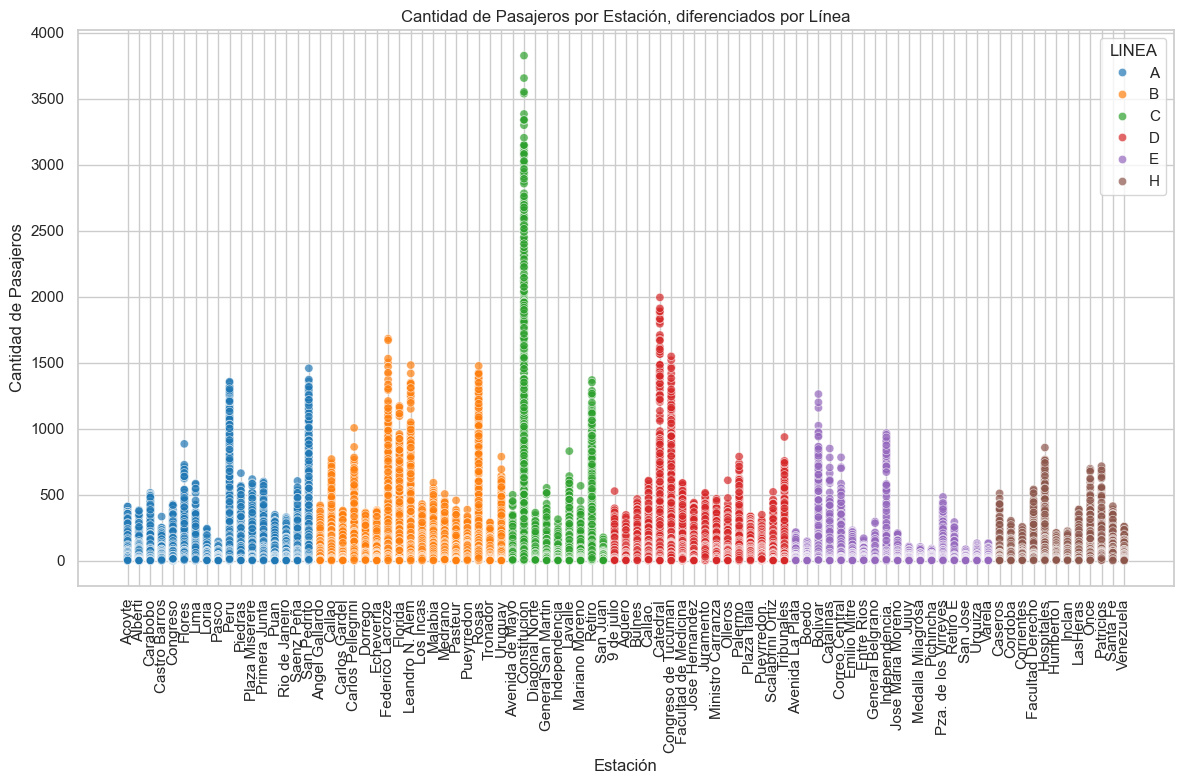

In [170]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='ESTACION', y='CANTIDAD', hue='LINEA', alpha=0.7, palette='tab10')
plt.xticks(rotation=90)
plt.ylabel('Cantidad de Pasajeros')
plt.xlabel('Estación')
plt.title('Cantidad de Pasajeros por Estación, diferenciados por Línea')
plt.tight_layout()
plt.show()

- A continuacion, se generan generan 2 gráficos de dispersión:

1. Por línea de subte, mostrando cómo varía la cantidad de pasajeros según la hora del día.
2. Por tramo horario del dia, mostrando cómo varía la cantidad de pasajeros según si es Mañana, Tarde, Noche o Madrugada.
2. Por tramo horario del dia, mostrando cómo varía la cantidad de pasajeros según si es Mañana, Tarde, Noche o Madrugada por Linea.

- Esto permite analizar visualmente los patrones horarios de demanda en cada línea.

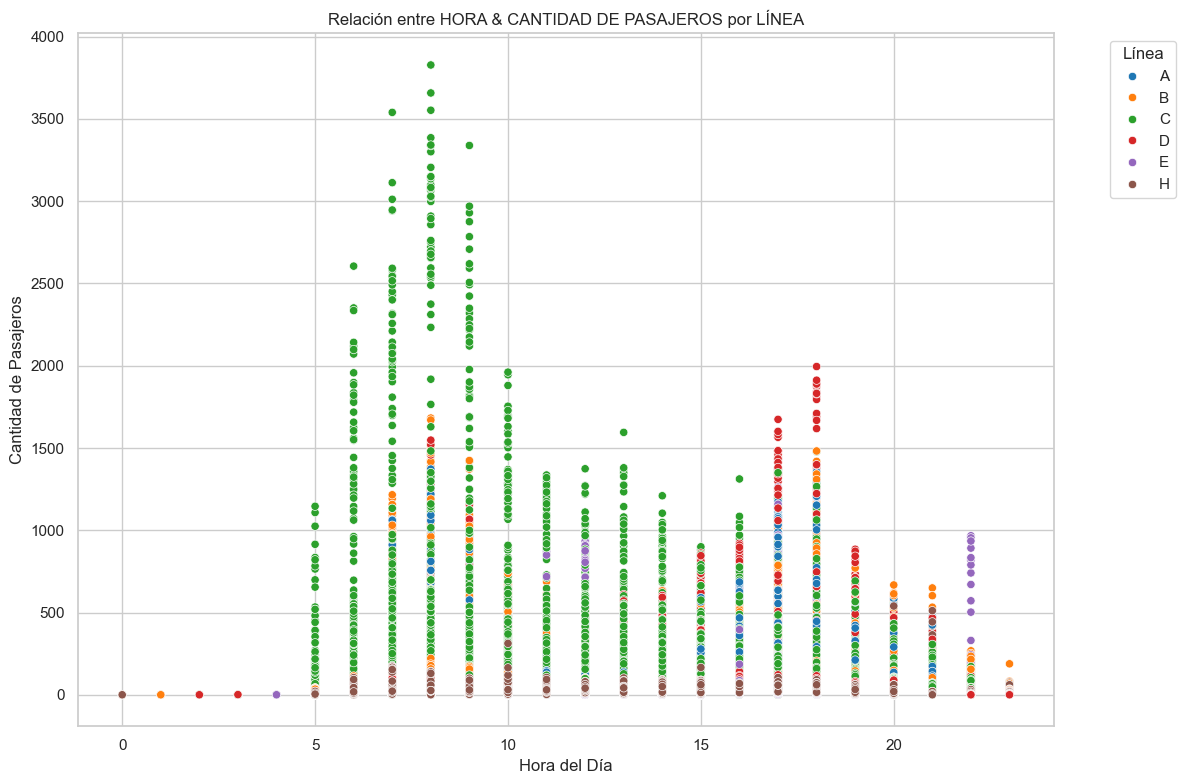

In [171]:
import seaborn as sns

#GRAFICO PARA PODER VISUALIZAR LA RELACION ENTRE HORA DE FUNCIONAMIENTO DEL SUBTE VS. PASAJEROS POR LINEA.
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x='HORA', y='CANTIDAD', hue='LINEA', palette='tab10')
plt.ylabel('Cantidad de Pasajeros')
plt.xlabel('Hora del Día')
plt.title('Relación entre HORA & CANTIDAD DE PASAJEROS por LÍNEA')
plt.legend(title='Línea', bbox_to_anchor=(1.05, 1), loc='upper left')  # Para ubicar la leyenda a la derecha
plt.tight_layout()
plt.show()

In [172]:
def clasificar_tramo(hora):
    if 6 <= hora < 12:
        return 'Mañana'
    elif 12 <= hora < 18:
        return 'Tarde'
    elif 18 <= hora < 24:
        return 'Noche'
    else:
        return 'Madrugada'

df['TRAMO_HORARIO'] = df['HORA'].apply(clasificar_tramo)

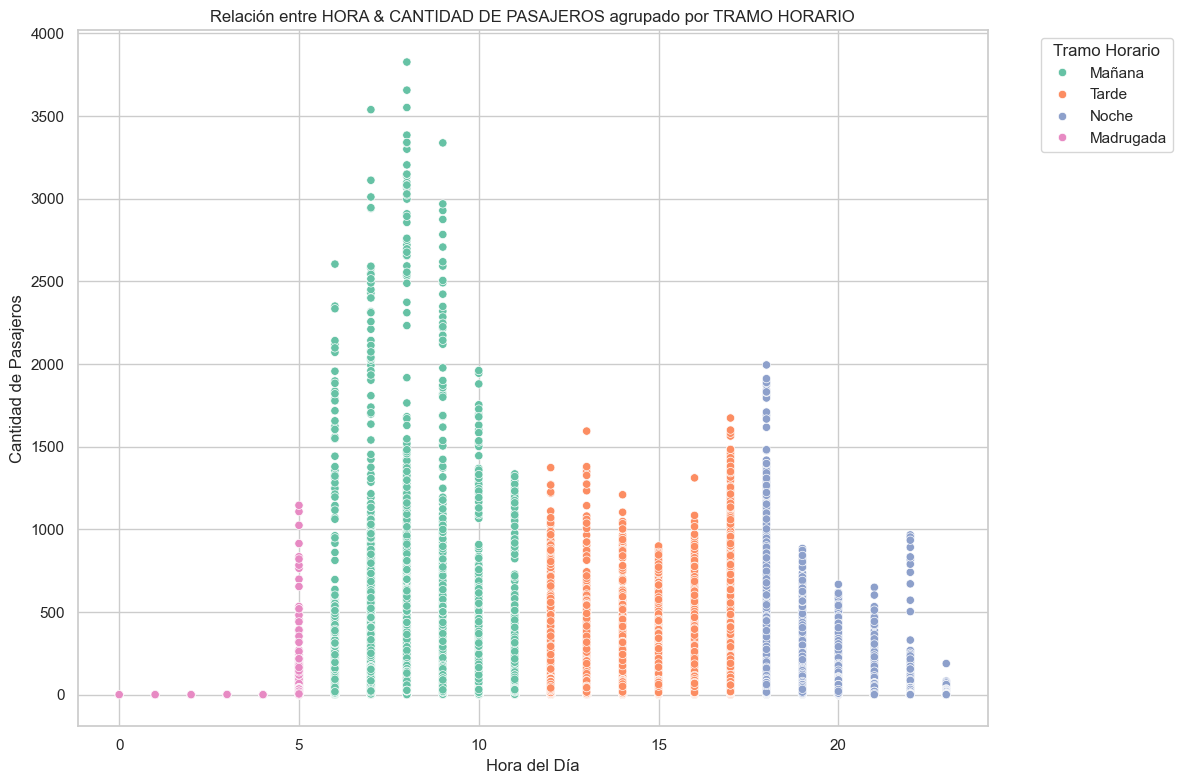

In [173]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x='HORA', y='CANTIDAD', hue='TRAMO_HORARIO', palette='Set2')
plt.ylabel('Cantidad de Pasajeros')
plt.xlabel('Hora del Día')
plt.title('Relación entre HORA & CANTIDAD DE PASAJEROS agrupado por TRAMO HORARIO')
plt.legend(title='Tramo Horario', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

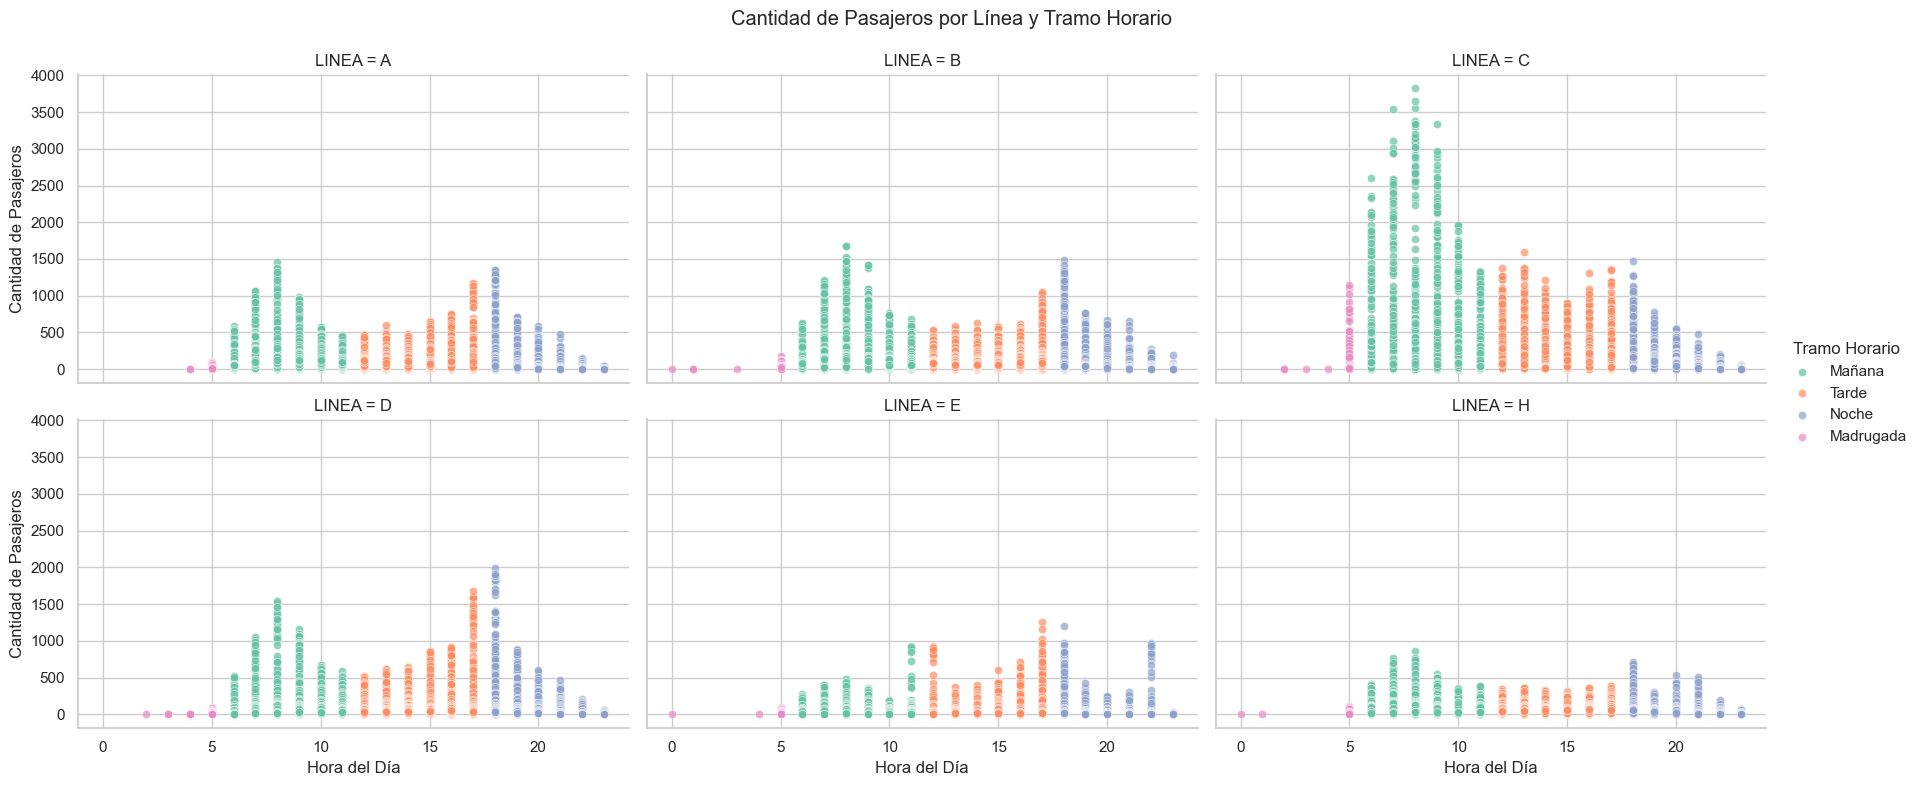

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear columna de tramos horarios
def clasificar_tramo(hora):
    if 6 <= hora < 12:
        return 'Mañana'
    elif 12 <= hora < 18:
        return 'Tarde'
    elif 18 <= hora < 24:
        return 'Noche'
    else:
        return 'Madrugada'

df['TRAMO_HORARIO'] = df['HORA'].apply(clasificar_tramo)

# 2. Crear grilla de gráficos: una por cada línea, con color por tramo horario
g = sns.FacetGrid(df, col="LINEA", hue="TRAMO_HORARIO", col_wrap=3, height=4, aspect=1.5, palette="Set2")
g.map(sns.scatterplot, "HORA", "CANTIDAD", alpha=0.7)
g.add_legend(title="Tramo Horario")
g.set_axis_labels("Hora del Día", "Cantidad de Pasajeros")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Cantidad de Pasajeros por Línea y Tramo Horario")

plt.show()

- El siguiente código genera una serie de gráficos de dispersión por línea de subte, mostrando cómo varía la cantidad de pasajeros según la hora del día.

- Esto te permite analizar visualmente los patrones horarios de demanda en cada línea.

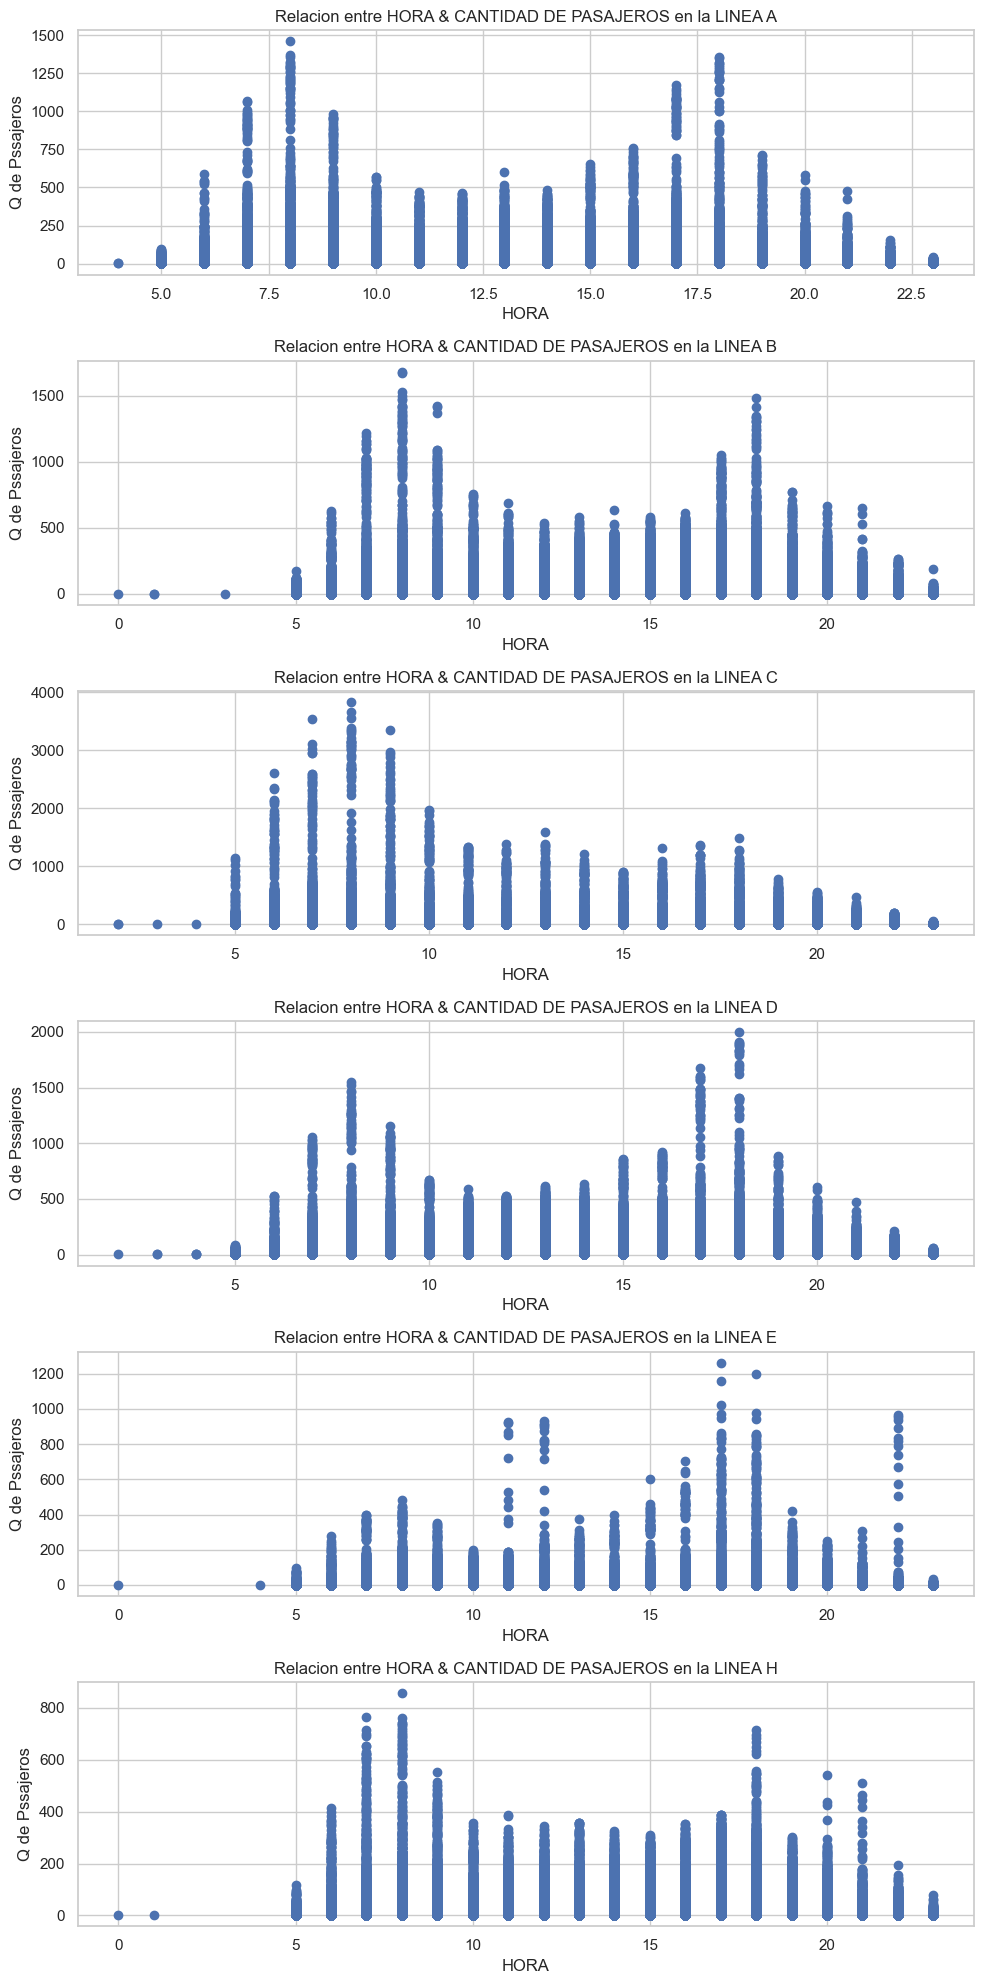

In [175]:
#GRAFICO PARA PODER VISUALIZAR LA RELACION ENTRE HORA DE FUNCIONAMIENTO DEL SUBTE VS. PASAJEROS POR LINEA.
#GRAFICO APERTURADO POR LINEA.

num_lineas = len(df['LINEA'].unique())

ig, axs = plt.subplots(nrows=num_lineas, ncols=1, figsize=(10, 20))

for i, linea in enumerate(df['LINEA'].unique()):
    df_linea = df[df['LINEA']== linea]
    axs[i].scatter(df_linea['HORA'], df_linea['CANTIDAD'])
    axs[i].set_title(f'Relacion entre HORA & CANTIDAD DE PASAJEROS en la LINEA {linea}')
    axs[i].set_ylabel('Q de Pssajeros')
    axs[i].set_xlabel('HORA')

plt.tight_layout()
plt.show()
    

- El siguiente código crea gráficos de dispersión individuales por línea de subte, mostrando la relación entre estaciones y cantidad de pasajeros para cada una:

- Este enfoque permite un análisis comparativo detallado por línea, útil para identificar estaciones con mayor afluencia

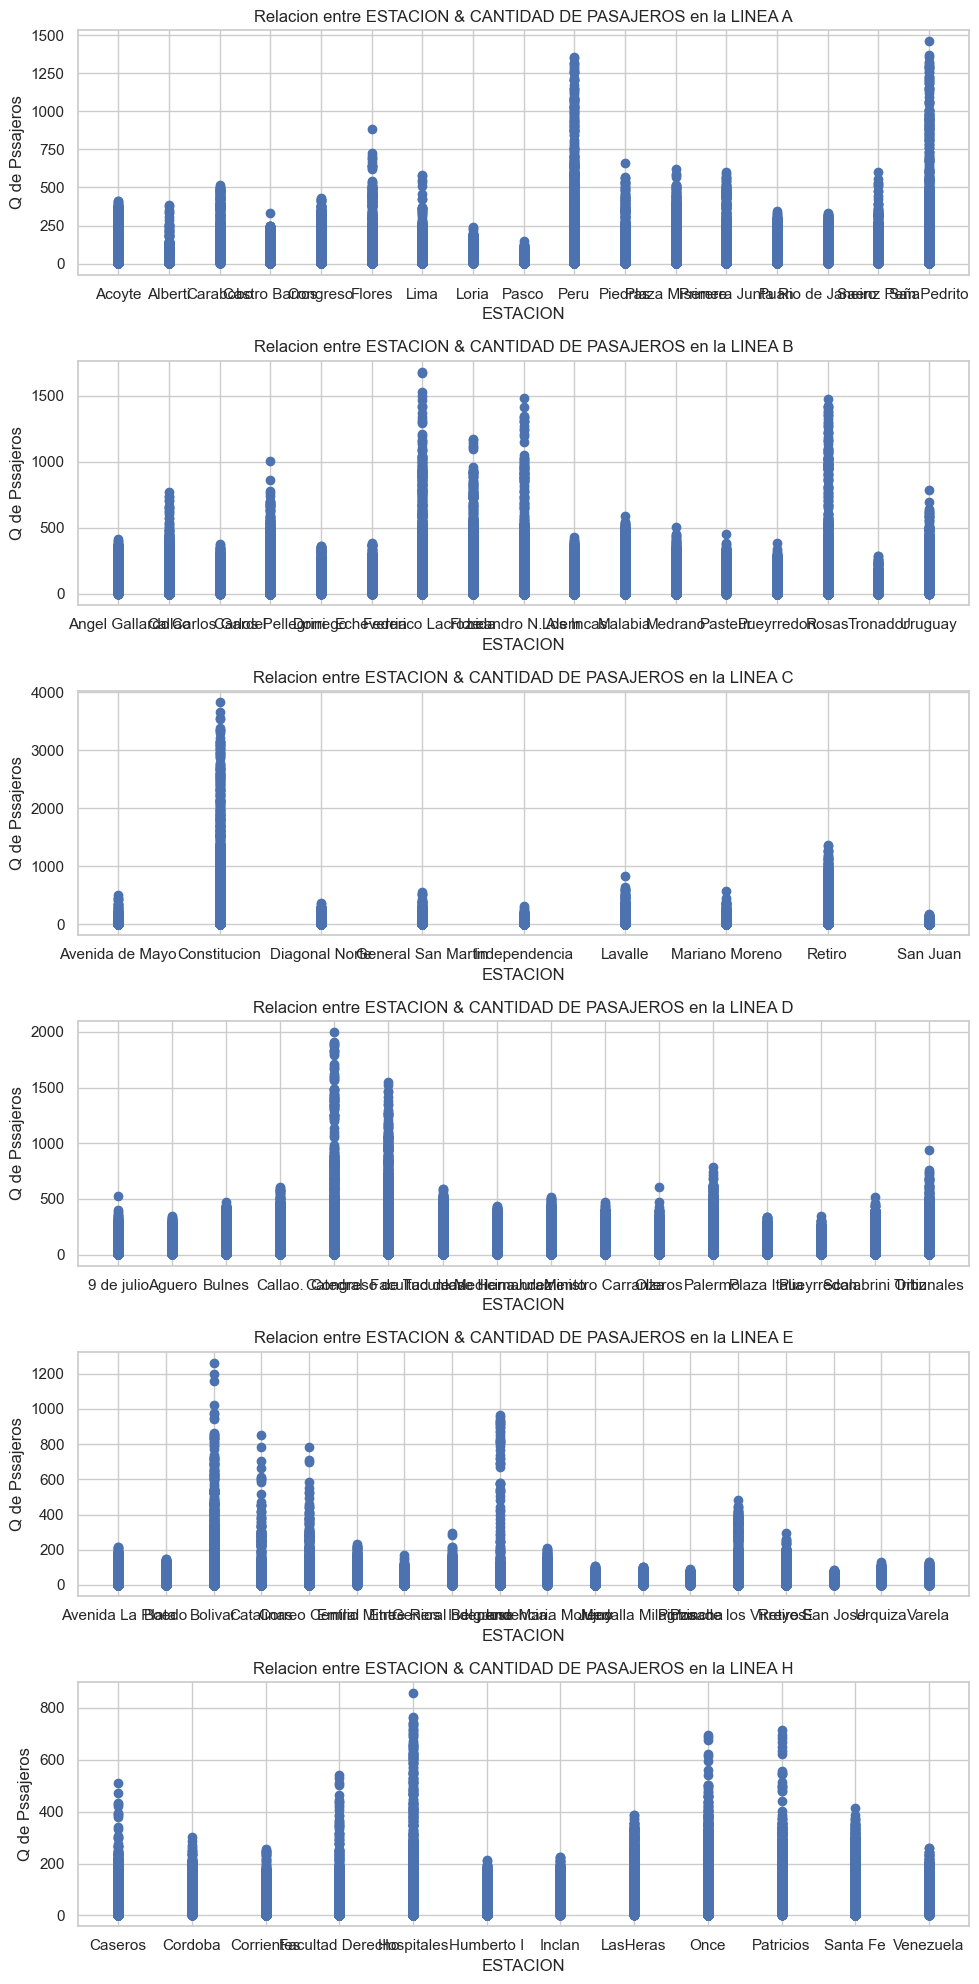

In [176]:
#GRAFICO PARA PODER VISUALIZAR LA RELACION ENTRE LAS ESTACIONES DEL SUBTE VS. PASAJEROS POR LINEA.
#GRAFICO APERTURADO POR LINEA.

num_lineas = len(df['LINEA'].unique())

ig, axs = plt.subplots(nrows=num_lineas, ncols=1, figsize=(10, 20))

for i, linea in enumerate(df['LINEA'].unique()):
    df_linea = df[df['LINEA']== linea]
    axs[i].scatter(df_linea['ESTACION'], df_linea['CANTIDAD'])
    axs[i].set_title(f'Relacion entre ESTACION & CANTIDAD DE PASAJEROS en la LINEA {linea}')
    axs[i].set_ylabel('Q de Pssajeros')
    axs[i].set_xlabel('ESTACION')

plt.tight_layout()
plt.show()

- El siguiente código genera un gráfico de dispersión que muestra la relación entre la hora del día y la cantidad de pasajeros, diferenciando cada línea de subte por color:

- Este tipo de visualización es ideal para detectar picos de demanda horaria y comparar cómo varía el flujo de pasajeros entre líneas en distintos momentos del día. 

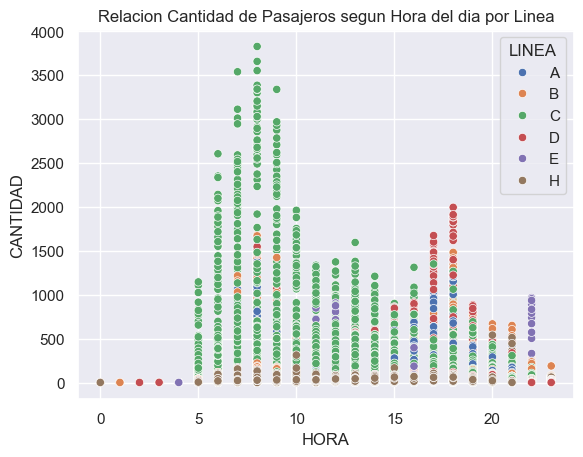

In [177]:
#GRAFICO PARA PODER VISUALIZAR LA RELACION ENTRE LAS CANTIDAD DE PASAJEROS  SEGUN LA HORA DEL DIA POR LINEA.


import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")

#LINEAS SEGMENTADAS POR COLOR.

sns.scatterplot(data=df, x="HORA", y="CANTIDAD", hue="LINEA")
plt.title('Relacion Cantidad de Pasajeros segun Hora del dia por Linea')

plt.show()

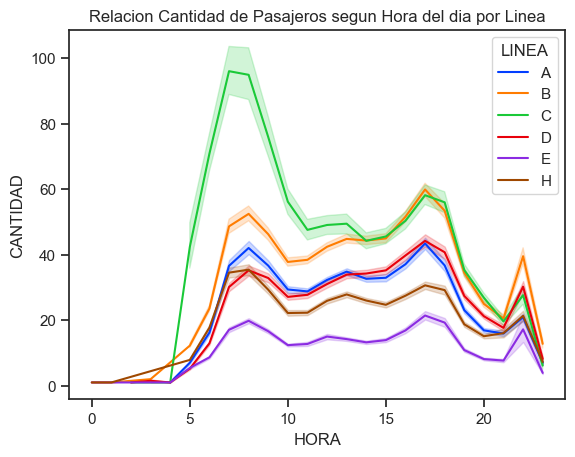

In [178]:
sns.set_theme(style="ticks", palette="bright")

sns.lineplot(data=df, x="HORA", y="CANTIDAD", hue="LINEA")
plt.title('Relacion Cantidad de Pasajeros segun Hora del dia por Linea')
plt.show()

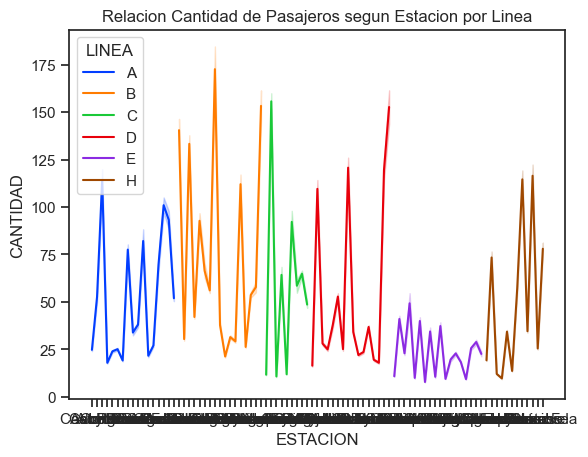

In [179]:
#GRAFICO DE LINEAS PARA ANALIZAR LA RELACION ENTRE LA CANTIDAD DE PASAJEROS Y LAS ESTACIONES POR LINEA.
#TODAS LAS LINEAS SEGMENTADAS POR COLOR.

sns.set_theme(style="ticks", palette="bright")

sns.lineplot(data=df, x="ESTACION", y="CANTIDAD", hue="LINEA")
plt.title('Relacion Cantidad de Pasajeros segun Estacion por Linea')
plt.show()

In [180]:
import numpy as np
from matplotlib.colors import ListedColormap

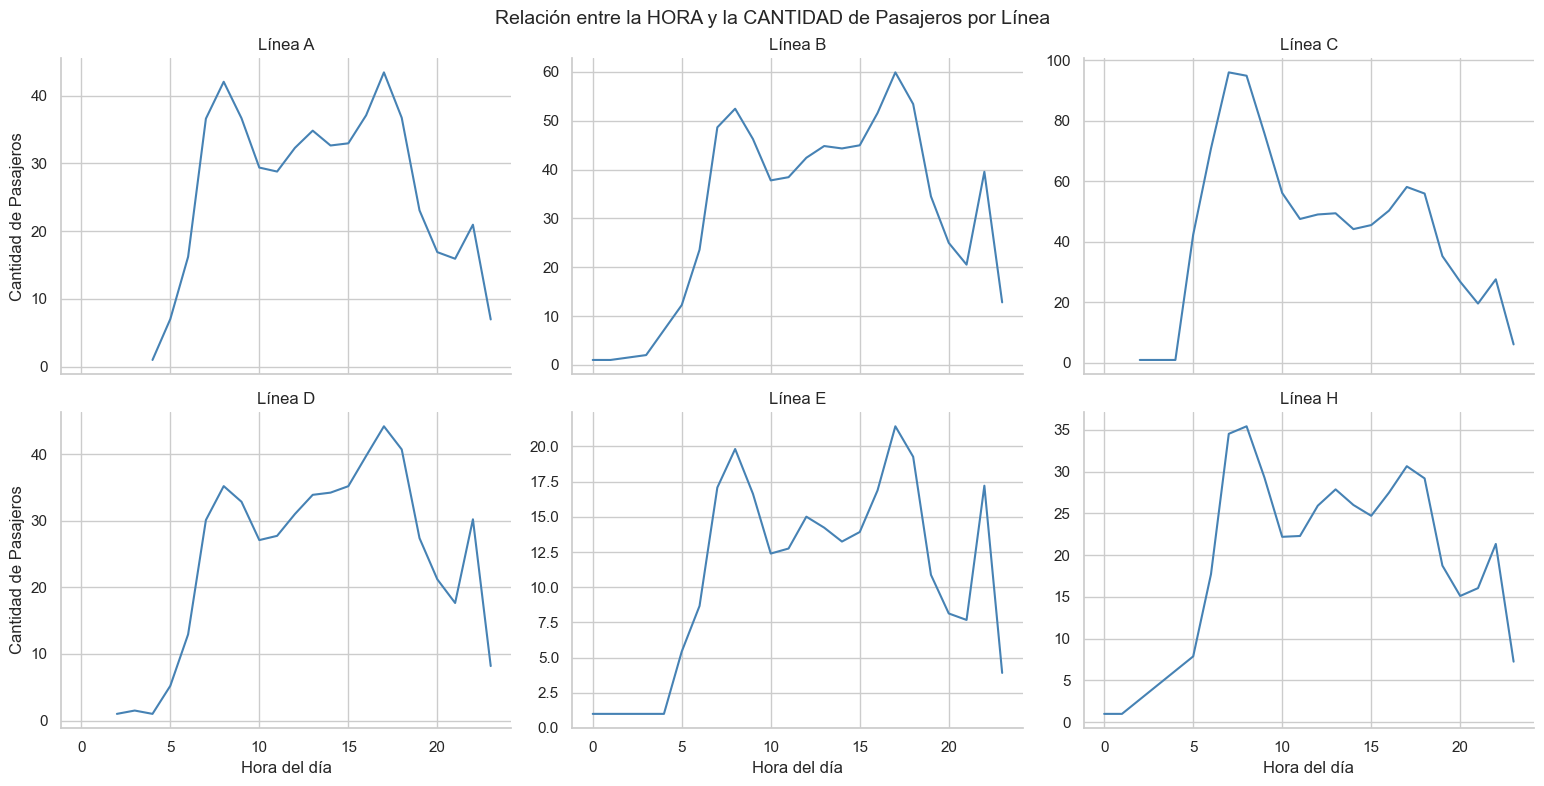

In [181]:

# Estilo visual
sns.set(style="whitegrid")

# Crear gráfico facetado con lineplot (sin regresión, solo tendencia)
g = sns.FacetGrid(df, col="LINEA", col_wrap=3, height=4, aspect=1.3, sharey=False)
g.map_dataframe(sns.lineplot, x="HORA", y="CANTIDAD", color='steelblue', estimator='mean', errorbar=None)

# Etiquetas y títulos
g.set_titles("Línea {col_name}")
g.set_axis_labels("Hora del día", "Cantidad de Pasajeros")
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle("Relación entre la HORA y la CANTIDAD de Pasajeros por Línea", fontsize=14)

# Mostrar gráfico
plt.show()

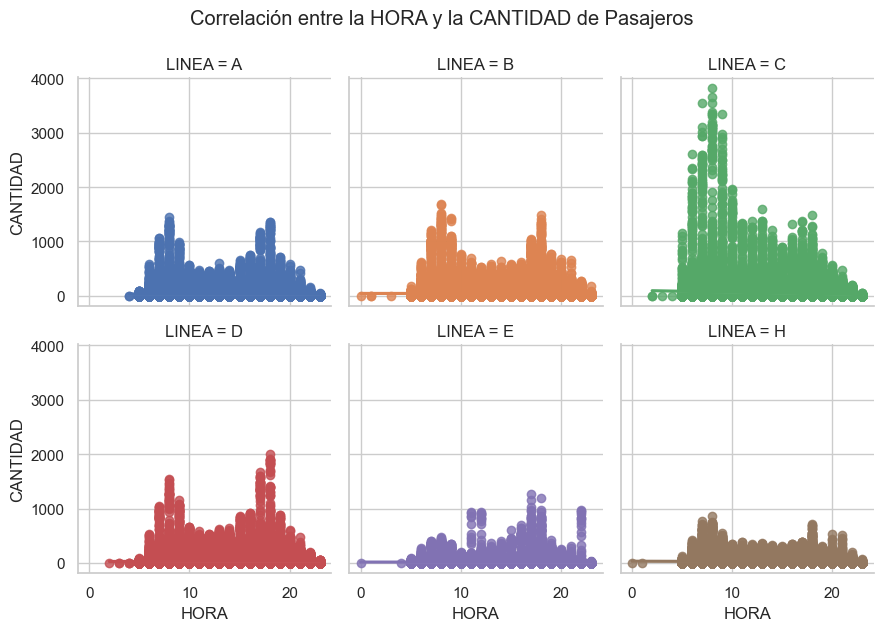

In [182]:
#GRAFICO LINEPLOT PARA ANALIZAR LA RELACION ENTRE LA CANTIDAD DE PASAJEROS Y LA HORA DEL DIA.
#APERTURADO POR LINEA SEGMENTADAS POR COLOR.

# Crea subplots para cada día
g = sns.lmplot(x="HORA", y="CANTIDAD", hue="LINEA", data=df, col="LINEA", col_wrap=3, height=3, aspect=1)

# Configura el título del gráfico
g.fig.suptitle("Correlación entre la HORA y la CANTIDAD de Pasajeros", y=1.05)

# Muestra el gráfico
plt.show()

In [183]:
df.columns

Index(['FECHA', 'ESTACION', 'LINEA', 'DESDE', 'HORA', 'CANTIDAD',
       'TRAMO_HORARIO'],
      dtype='object')

**ALGUNAS CONCLUSIONES**

In [184]:
print('Conclusiones: MAXIMOS')
print('Linea con MAYOR cantidad de viajes es:', df.groupby('LINEA')['CANTIDAD'].sum().idxmax())
print('La Hora con MAYOR cantidad de viajes es:', df.groupby('HORA')['CANTIDAD'].sum().idxmax())
print('La Estacion con MAYOR cantidad de viajes es:', df.groupby('ESTACION')['CANTIDAD'].sum().idxmax())

print('Conclusiones: MINIMOS')
print('Linea con MENOR cantidad de viajes es:', df.groupby('LINEA')['CANTIDAD'].sum().idxmin())
print('La Hora con MENOR cantidad de viajes es:', df.groupby('HORA')['CANTIDAD'].sum().idxmin())
print('La Estacion con MENOR cantidad de viajes es:', df.groupby('ESTACION')['CANTIDAD'].sum().idxmin())

Conclusiones: MAXIMOS
Linea con MAYOR cantidad de viajes es: B
La Hora con MAYOR cantidad de viajes es: 17
La Estacion con MAYOR cantidad de viajes es: Constitucion
Conclusiones: MINIMOS
Linea con MENOR cantidad de viajes es: E
La Hora con MENOR cantidad de viajes es: 0
La Estacion con MENOR cantidad de viajes es: Medalla Milagrosa


In [185]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA




In [186]:
df.dtypes

FECHA            datetime64[ns]
ESTACION                 object
LINEA                    object
DESDE                    object
HORA                      int64
CANTIDAD                  int64
TRAMO_HORARIO            object
dtype: object

In [187]:
df.columns

Index(['FECHA', 'ESTACION', 'LINEA', 'DESDE', 'HORA', 'CANTIDAD',
       'TRAMO_HORARIO'],
      dtype='object')

In [188]:
#CREO UN NUEVO DATAFRAME PARA PODER APLICAR EL ALGORITMO DE K-MEANS.

df2 = df

- Detalle del siguiente codigo:

- 1 Convierte la columna HORA a formato de hora (si está en formato datetime) y extrae solo la hora en formato numérico (0 a 23).
- 2 Transforma la columna categórica ESTACION en valores numéricos, útiles para modelos de machine learning.
- 3 Se instancia un codificador de etiquetas (LabelEncoder) de sklearn, ideal para convertir categorías de texto a números.
- 4 Aplica el codificador a la columna LINEA, generando una nueva columna LINEA_NUM con los valores codificados como enteros.


In [189]:
df2['HORA']= pd.to_datetime(df2['HORA']).dt.hour
df2['ESTACION_NUMERICA']=pd.Categorical(df2['ESTACION']).codes

#CONVIERTO LINEA STRING a FLOAT
le= LabelEncoder()
df2["LINEA_NUM"]= le.fit_transform(df2['LINEA'])

- Se crea un nuevo DataFrame "df_scale" que contiene únicamente las variables seleccionadas (features) que serán utilizadas para entrenar el modelo.

In [190]:
#Features seleccionadas para el modelo.
df_scale=df2[['HORA','CANTIDAD','LINEA_NUM','ESTACION_NUMERICA']]


- Se aplica la técnica de escalado estándar (StandardScaler) para normalizar las variables seleccionadas.
- Este procedimiento transforma los datos para que cada feature tenga media cero y desviación estándar uno, lo cual mejora el rendimiento y la convergencia de muchos modelos de machine learning.
- El resultado (df_scale) es una matriz numpy lista para ser utilizada en el entrenamiento del modelo.

In [191]:
#Escalado de datos para facilitar la convergencia del modelo.
scaler = StandardScaler()
df_scale = scaler.fit_transform(df_scale)


- Luego, aplico el algoritmo K-Means para agrupar los datos escalados en k=5 clusters.
- El modelo se inicializa con el método k-means++, un máximo de 500 iteraciones y una tolerancia de 0.0001 para mejorar la estabilidad de la convergencia.
- Tras el entrenamiento con fit(), las etiquetas asignadas a cada observación se almacenan en etiquetas_kmeans.
- Finalmente, se incorpora una nueva columna cluster al DataFrame original (df2) con la asignación de cada punto a su grupo correspondiente.

In [192]:
#K-mmeans
#ingreso la cantidad de clusters.

k=5

km = KMeans(n_clusters=k, init="k-means++", max_iter=500, tol=1e-4, random_state=42)
km.fit(df_scale)
etiquetas_kmeans = km.labels_

df2['cluster'] = etiquetas_kmeans

- Se recorre cada uno de los k clusters generados y se filtran las filas correspondientes en el DataFrame original.
- Luego, se imprime un resumen estadístico (describe()) de cada grupo para analizar sus características principales.

In [193]:
#Visualizo los clusters generados.
for i in range(k):
    cluster_i = df2[df2['cluster'] == i]
    print (f'Cluster {i}:')
    print(cluster_i.describe())

Cluster 0:
                               FECHA      HORA       CANTIDAD  \
count                         183100  183100.0  183100.000000   
mean   2020-07-03 11:18:20.487165440       0.0      21.732463   
min              2020-03-01 00:00:00       0.0       1.000000   
25%              2020-04-23 00:00:00       0.0       5.000000   
50%              2020-07-03 00:00:00       0.0      12.000000   
75%              2020-09-11 00:00:00       0.0      25.000000   
max              2020-11-19 00:00:00       0.0     246.000000   
std                              NaN       0.0      31.189085   

       ESTACION_NUMERICA      LINEA_NUM   cluster  
count      183100.000000  183100.000000  183100.0  
mean           62.508782       3.674402       0.0  
min            41.000000       3.000000       0.0  
25%            56.000000       3.000000       0.0  
50%            59.000000       3.000000       0.0  
75%            72.000000       4.000000       0.0  
max            88.000000       5.000000

**Visualizacion Grafica**

/var/folders/mc/x95ytzzn5z35gdz502qgy2f80000gn/T/ipykernel_29353/1065401786.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Set2', k),


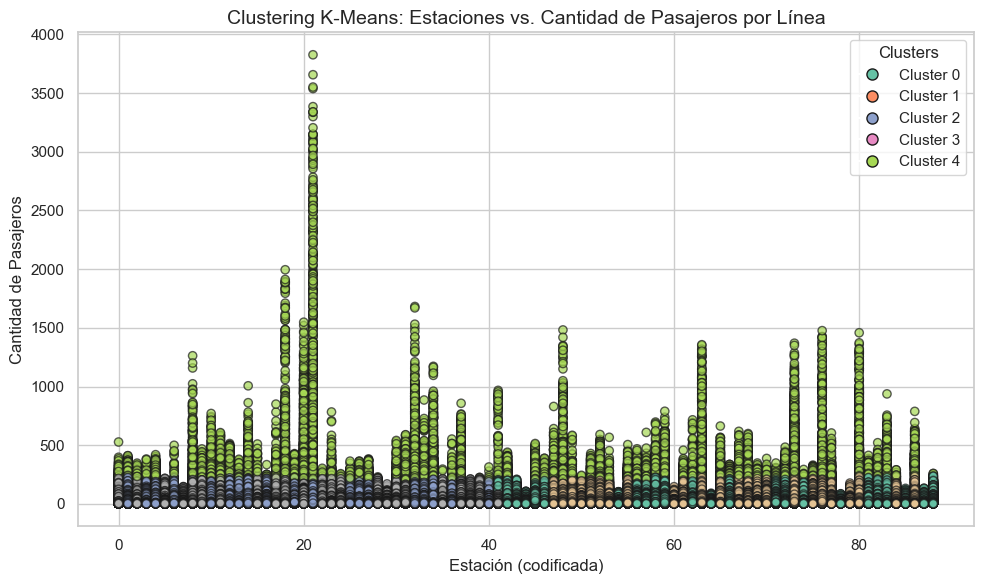

In [194]:

# Definir una paleta de colores
palette = sns.color_palette('Set2', n_colors=k)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df2['ESTACION_NUMERICA'],
    df2['CANTIDAD'],
    c=df2['cluster'],
    cmap=plt.cm.get_cmap('Set2', k),
    alpha=0.7,
    edgecolors='k'
)

plt.title('Clustering K-Means: Estaciones vs. Cantidad de Pasajeros por Línea', fontsize=14)
plt.xlabel('Estación (codificada)', fontsize=12)
plt.ylabel('Cantidad de Pasajeros', fontsize=12)
plt.grid(True)

# Agregar leyenda manual
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Cluster {i}',
                          markerfacecolor=palette[i], markersize=8, markeredgecolor='k') for i in range(k)]
plt.legend(handles=legend_elements, title="Clusters")

plt.tight_layout()
plt.show()

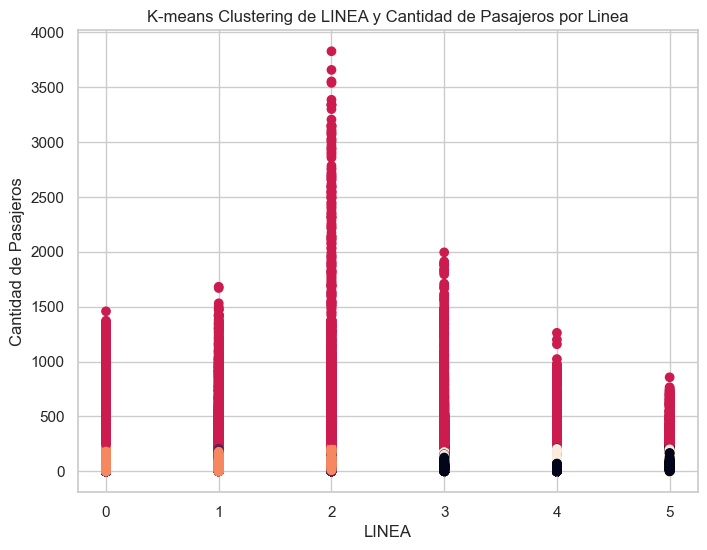

In [195]:
#GRAFICO DE CLUSTERING K-MEANS PARA ANALIZAR LA CANTIDAD DE PASAJEROS POR LINEA.

plt. figure (figsize= (8, 6) )
plt. scatter(df2['LINEA_NUM'], df2['CANTIDAD'], c=df2['cluster'])
plt. title( 'K-means Clustering de LINEA y Cantidad de Pasajeros por Linea')
plt. xlabel ('LINEA')
plt. ylabel ('Cantidad de Pasajeros')
plt. show ()

## INICIO DE ETEPA DE ENTRENAMIENTO

In [196]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


SEPARACION DE DATOS PARA EL ENTRENAMIENTO

In [197]:
df.columns

Index(['FECHA', 'ESTACION', 'LINEA', 'DESDE', 'HORA', 'CANTIDAD',
       'TRAMO_HORARIO', 'ESTACION_NUMERICA', 'LINEA_NUM', 'cluster'],
      dtype='object')

In [198]:
df.head(10)

,FECHA,ESTACION,LINEA,DESDE,HORA,CANTIDAD,TRAMO_HORARIO,ESTACION_NUMERICA,LINEA_NUM,cluster
0,2020-03-01,Acoyte,A,7:45,0,20,Mañana,1,0,1
1,2020-03-01,Acoyte,A,8:00,0,16,Mañana,1,0,1
2,2020-03-01,Acoyte,A,8:15,0,22,Mañana,1,0,1
3,2020-03-01,Acoyte,A,8:30,0,27,Mañana,1,0,1
4,2020-03-01,Acoyte,A,8:45,0,37,Mañana,1,0,1
5,2020-03-01,Acoyte,A,9:00,0,59,Mañana,1,0,1
6,2020-03-01,Acoyte,A,9:15,0,32,Mañana,1,0,1
7,2020-03-01,Acoyte,A,9:30,0,27,Mañana,1,0,1
8,2020-03-01,Acoyte,A,9:45,0,26,Mañana,1,0,1
9,2020-03-01,Acoyte,A,10:00,0,35,Mañana,1,0,1


In [199]:
#CREO UN NUEVO DATAFRAME PARA PODER TRANSFORMAR LOS VALORAS A NUMERICOS.
df3=df

In [200]:
#CONVERTIR LINEA STRING a FLOAT. ( CONVIERTE LOS DATOS DE LAS COLUMNAS SELECCIONADAS A VALORES NUMERICOS)

df3['FECHA_NUMERICA']= pd.to_numeric(pd.to_datetime(df3['FECHA']).apply(lambda x: x.timestamp()))
df3['HORA']= pd.to_datetime(df3['HORA']).dt.hour
df3['LINEA_NUMERICA']=pd.Categorical(df3['LINEA']).codes

In [201]:
#CONVIERTO LA COLUMNAS DESDE(HORA) A VALORES NUMERICOS.
df3['DESDE_NUMERICA']=pd.Categorical(df3['DESDE']).codes

In [202]:
#COVIERTO LA COLUMNA ESTACION A VALORES NUMERICOS.
df3['ESTACION_NUMERICA']=pd.Categorical(df3['ESTACION']).codes

In [203]:
#SELECCIONO LA COLUMNA QUE VOY A UTILIZAR COMO TARGET.
target='CANTIDAD'


In [204]:
df3.columns

Index(['FECHA', 'ESTACION', 'LINEA', 'DESDE', 'HORA', 'CANTIDAD',
       'TRAMO_HORARIO', 'ESTACION_NUMERICA', 'LINEA_NUM', 'cluster',
       'FECHA_NUMERICA', 'LINEA_NUMERICA', 'DESDE_NUMERICA'],
      dtype='object')

In [205]:
df3.sample(5)

,FECHA,ESTACION,LINEA,DESDE,HORA,CANTIDAD,TRAMO_HORARIO,ESTACION_NUMERICA,LINEA_NUM,cluster,FECHA_NUMERICA,LINEA_NUMERICA,DESDE_NUMERICA
640423,2020-09-21,Lima,A,20:30,0,10,Noche,49,0,3,1.600646e+09,0,68
372534,2020-06-22,Malabia,B,16:00,0,33,Tarde,52,1,3,1.592784e+09,1,48
426729,2020-07-10,Facultad Derecho,H,17:30,0,3,Tarde,30,5,4,1.594339e+09,5,54
288748,2020-05-24,Congreso,A,13:30,0,2,Tarde,19,0,1,1.590278e+09,0,38
519535,2020-08-11,Independencia,C,12:00,0,16,Tarde,40,2,1,1.597104e+09,2,32


In [206]:
#SELECCIONO LAS COLUMNAS QUE VOY A UTILIZAR COMO FEATURES TANTO PARA X COMO PARA Y.
df3=df3[['ESTACION_NUMERICA', 'DESDE_NUMERICA', 'HORA', 'CANTIDAD',
       'HORA', 'FECHA_NUMERICA', 'LINEA_NUMERICA']]
x=df3[['DESDE_NUMERICA', 'HORA', 'LINEA_NUMERICA'
       , 'FECHA_NUMERICA', 'ESTACION_NUMERICA']]
y=df3[target]

# Modelo : "Ridge". StandardScaler + Select Kbest.

In [207]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn. feature_selection import SelectKBest
from sklearn. linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error


- Se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) para evaluar el rendimiento del modelo.
- Luego, se aplica StandardScaler para estandarizar las variables predictoras, ajustándolas a una media de 0 y desviación estándar de 1. 
- Esto mejora la eficiencia y precisión de los algoritmos de machine learning, especialmente aquellos sensibles a la escala de los datos.

In [208]:
#DIVIDO LOS DATOS EN TRAIN Y TEST.

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#Utilizo la clasa StandardScaler para escalar los datos de manera que tengan una media 0 y una desviación estándar 1.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



- Este fragmento divide los datos en conjuntos de entrenamiento y prueba (80/20) para evaluar el modelo. 
- Luego se aplica StandardScaler para normalizar las variables predictoras, centrando los datos en 0 y ajustando la desviación estándar a 1, lo cual es esencial para algoritmos sensibles a la escala, como regresión logística, SVM o redes neuronales.

In [209]:
#SELECCIONO LAS MEJORES FEATURES PARA EL MODELO CON EL METODO DE SELECTKBEST..
#UTILIZO EL MODELO SELECTKBEST PARA SELECCIONAR LAS MEJORES CARACTERISTICAS.
#INGRESAR LA CANTIDAD DE FEATURES QUE DESEAMOS SELECCIONAR.
selectk = 4

selector = SelectKBest(k=selectk)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [1 2] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


**X_train_scaled / X_test_scaled = 8 (Features Originales del Dataset)**
**X_train_selected / X_test_selected = SelectKBest = K = 4**

In [210]:
print(selector.get_support())

[ True False False  True  True  True]


- El siguente codigo, permite visualizar las variables más relevantes seleccionadas por SelectKBest.

- Esto ayuda a simplificar el modelo y mejorar su rendimiento reduciendo el ruido.

In [211]:
#VISUALIZO LAS FEATURES SELECCIONADAS POR SELECTKBEST.

caracteristicas = selector.get_support()
caracteristicas_selec = X_train.columns[caracteristicas]
print(' Features Seleccionadas por KBest')
print(caracteristicas_selec)

 Features Seleccionadas por KBest
Index(['DESDE_NUMERICA', 'LINEA_NUMERICA', 'FECHA_NUMERICA',
       'ESTACION_NUMERICA'],
      dtype='object')


- El siguiente codigo, crea una instancia del modelo Ridge Regression.
- El parámetro alpha=0.1 controla la penalización: valores más altos reducen la magnitud de los coeficientes, ayudando a evitar el sobreajuste.
	

In [212]:
ridge = Ridge(alpha=0.1)

In [213]:
ridge.fit(X_train_selected, y_train)

Ridge(alpha=0.1)

- Metricas de rendmiento.

In [214]:
scores = cross_val_score(ridge,X_train_selected, y_train, cv=5)
print(' R2 cercano a 1 = Exitoso ( El modelo SI explica gran proporcion de la Varianza)')
print(' R2 cercano a 0 = No Exitoso( El modelo NO explica gran parte de la Varianza)')
print('       ')
print('Precision del modelo:', scores.mean())


 R2 cercano a 1 = Exitoso ( El modelo SI explica gran proporcion de la Varianza)
 R2 cercano a 0 = No Exitoso( El modelo NO explica gran parte de la Varianza)
       
Precision del modelo: 0.048511231674930655


In [215]:
#REALIZO LAS PREDICCIONES CON EL MODELO.
y_pred = ridge.predict(X_test_selected)

In [300]:
reg_score=r2_score(y_test,y_pred)
print(reg_score)

mse=mean_squared_error(y_test,y_pred)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.04640470663182861
5655.211215945906
7520.1138395279
R2 (Coeficiente de Determinacion): 0.04640470663182861
MSE (Error Cuadratico Medio): 5655.211215945906
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 75.201138395279


In [217]:
print(X_train_selected.shape,X_test_selected.shape,y_train.shape,y_test.shape)


(657890, 4) (164473, 4) (657890,) (164473,)


- VISUAIZACIONES GREAFICAS DE LOS RESULTADOS.

In [218]:
import scipy.stats as stats

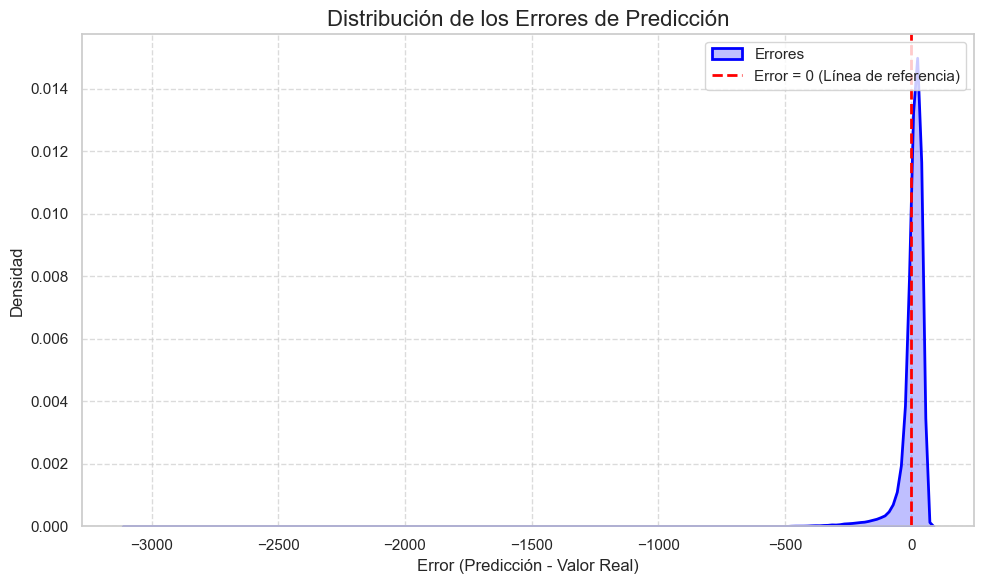

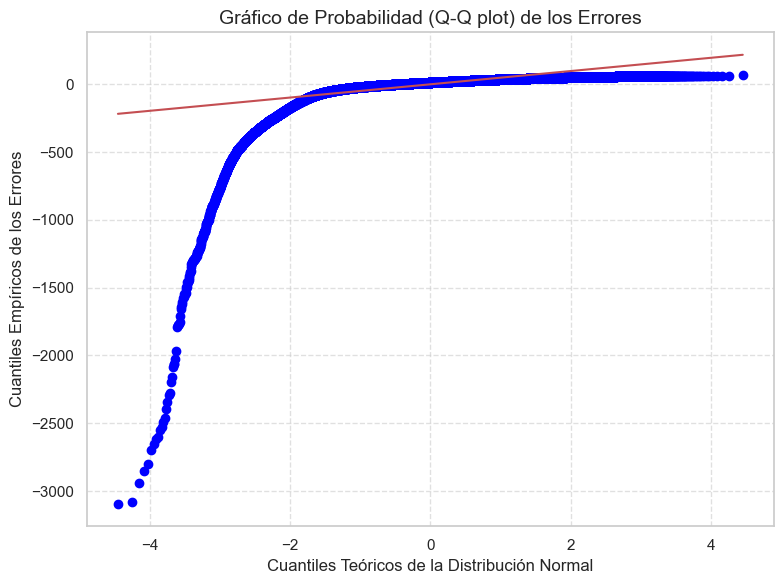

In [ ]:
# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = y_pred - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#GRAFICO Q-Q PLOT PARA ANALIZAR LA NORMALIDAD DE LOS ERRORES.

# Calcular los errores
errores = y_pred - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [303]:
#VISUALIZON LOS RESULTADOS DE LA PREDCCION Y LOS COMPARO CON LOS DATOS REALES.

predicciones = df3
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': y_pred, 'Dif': y_test-y_pred})
print('Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)
        Datos Reales  Predicciones    Dif
652969            22          26.6   -4.6
251617             9          42.5  -33.5
1071              10          59.3  -49.3
559734            43          32.9   10.1
702910             1           6.7   -5.7
716474             5          15.4  -10.4
229501            35          51.7  -16.7
361757           281          34.0  247.0
797460             1          -1.1    2.1
34681             93          64.5   28.5
257081             5          43.0  -38.0
7204              39          51.0  -12.0
301164            21          36.8  -15.8
70927            168          61.1  106.9
312862             6          32.7  -26.7
328364             3          30.4  -27.4
419687            13          37.9  -24.9
163203             3          55.4  -52.4
73936             67          51.1   15.9
785421             2          -1.3    3.3


**Conclusion del Modelo RIDGE** 
- Modelo de Prediccion DEFICIENTE. Poco Exacto.

- El modelo de Regresión Ridge con alpha=0.1 (en este caso),  apenas predce la variable objetivo.

- El rendimiento del modelo es bajo, lo que sugiere que las variables seleccionadas no son suficientes o no tienen una relación lineal fuerte con el target. 
- Sería recomendable:
	•	Explorar otras combinaciones de features.
	•	Probar con mayor regularización (alpha más alto).
	•	Evaluar modelos no lineales o incorporar ingeniería de variables adicionales.

# Modelo : "LinearRegression" + MinMaxScaler.

In [222]:
from sklearn import linear_model




- El siguiente codigo, crea una instancia del modelo de regresión lineal.
- Este modelo busca ajustar una línea recta (o un hiperplano en múltiples dimensiones) que minimice la suma de los errores cuadrados entre las predicciones y los valores reales.
- Es un modelo base, sin regularización, ideal para establecer una línea de base en problemas de regresión.

In [223]:
reg=linear_model.LinearRegression()

- Se entrena el modelo de regresión lineal utilizando los datos escalados de entrenamiento (X_train_scaled) y sus valores objetivo (y_train). 
- Durante este proceso, el modelo calcula los coeficientes que mejor se ajustan a los datos minimizando el error cuadrático.

In [224]:
reg.fit(X_train_scaled,y_train)


LinearRegression()

- El siguientecódigo aplica escalado Min-Max a los datos, transformándolos para que todos los valores de las variables estén en un rango entre 0 y 1. 
- Esto es útil para algoritmos sensibles a la escala, como redes neuronales o K-means, y mejora la convergencia del entrenamiento. 
- Se ajusta el escalador (fit_transform) sobre los datos de entrenamiento y luego se aplica (transform) al conjunto de prueba y al conjunto completo x para asegurar consistencia.

In [225]:
from matplotlib import transforms
from sklearn.preprocessing import MinMaxScaler, minmax_scale

#ESCALADO DE DATOS PARA FACILITAR LA CONVERGENCIA DEL MODELO.
minmax_scaler=MinMaxScaler()
X_train_selected=minmax_scaler.fit_transform(X_train_scaled)
X_test_selected=minmax_scaler.transform(X_test_scaled)
x=minmax_scaler.transform(x)



/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


- Metricas de rendmiento.

In [226]:
reg.score(X_train_scaled,y_train)


0.048510132409050555

In [227]:
reg.intercept_

31.995108604781738

In [228]:
reg.coef_

array([-1.34402747e+00,  0.00000000e+00, -1.11022302e-16, -6.03511032e+00,
       -1.57399811e+01,  6.10495556e-01])

- El siguiente codigo, utiliza el modelo de regresión lineal previamente entrenado (reg) para predecir los valores de la variable objetivo (y) sobre el conjunto de prueba ya escalado (X_test_scaled). 
- El resultado (y_predLR) contiene las predicciones generadas por el modelo.

In [229]:
y_predLR=reg.predict(X_test_scaled)

In [230]:
y_predLR

array([26.59326395, 42.46964497, 59.27924877, ..., 44.27573144,
       20.55315335, 31.11581497])

In [231]:
y_test.values

array([22,  9, 10, ..., 12, 14,  6])

**Metricas de rendmiento**

In [232]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

reg_score=r2_score(y_test,y_predLR)
print(reg_score)

mse=mean_squared_error(y_test,y_predLR)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.04640470643805927
5655.211217095038
7520.11384029194
R2 (Coeficiente de Determinacion): 0.04640470643805927
MSE (Error Cuadratico Medio): 5655.211217095038
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 75.2011384029194


- VISUAIZACIONES GRAFICAS DE LOS RESULTADOS.

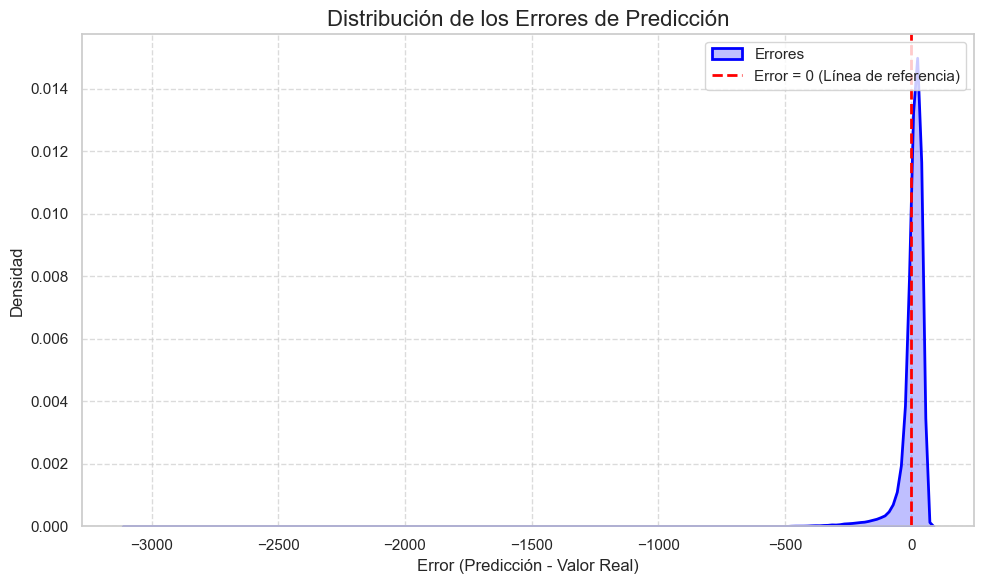

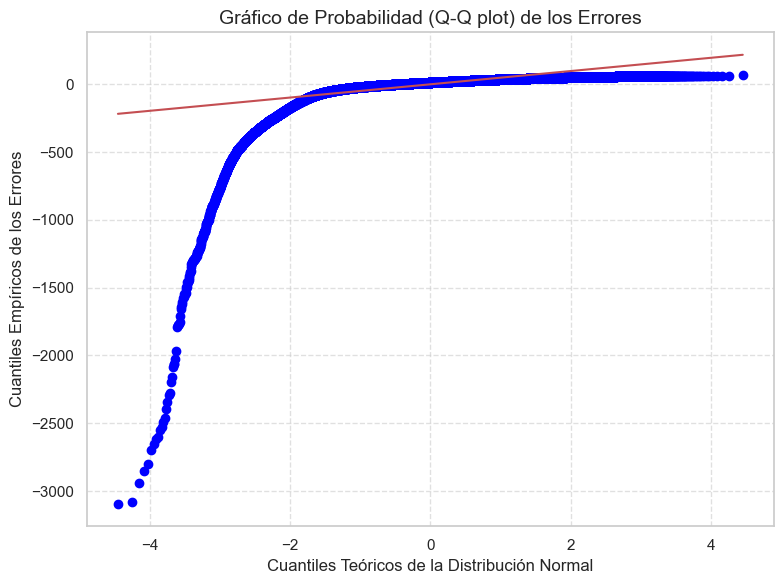

In [ ]:
#GRAFICO DE LINE

# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = y_predLR - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#GRAFICO Q-Q PLOT PARA ANALIZAR LA NORMALIDAD DE LOS ERRORES.

# Calcular los errores
errores = y_predLR - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [305]:
#VISUALIZON LOS RESULTADOS DE LA PREDCCION Y LOS COMPARO CON LOS DATOS REALES.

predicciones = df3
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': y_predLR, 'Dif': y_test-y_predLR})
print('Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)
        Datos Reales  Predicciones    Dif
652969            22          26.6   -4.6
251617             9          42.5  -33.5
1071              10          59.3  -49.3
559734            43          32.9   10.1
702910             1           6.7   -5.7
716474             5          15.4  -10.4
229501            35          51.7  -16.7
361757           281          34.0  247.0
797460             1          -1.1    2.1
34681             93          64.5   28.5
257081             5          43.0  -38.0
7204              39          51.0  -12.0
301164            21          36.8  -15.8
70927            168          61.1  106.9
312862             6          32.7  -26.7
328364             3          30.4  -27.4
419687            13          37.9  -24.9
163203             3          55.4  -52.4
73936             67          51.1   15.9
785421             2          -1.3    3.3


**Conclusion del Modelo LINEAR REGRESSION** 
- Modelo de Prediccion DEFICIENTE. Poco Exacto.

- El modelo presenta un desempeño deficiente en la predicción de la variable objetivo, evidenciado por una baja precisión.
- Los resultados sugieren que las variables seleccionadas no capturan adecuadamente la relación con la variable dependiente o que dicha relación no es lineal.
- Para mejorar el rendimiento, se recomienda:
1. Evaluar nuevas combinaciones de features.
2. Considerar un aumento en la regularización (mayor valor de alpha).
3. Explorar modelos no lineales y aplicar técnicas de ingeniería de variables para mejorar la representación de los datos.


# Modelo : "DecisionTreeRegressor". 

**max_depth=3**

In [236]:
from sklearn.tree import DecisionTreeRegressor


- Este fragmento de código implementa un modelo de árbol de decisión para regresión, con una profundidad máxima de 3. 
- Detalle del codigo:
	1.	tree_mod=DecisionTreeRegressor(max_depth=3): se crea un modelo de regresión basado en árboles de decisión, limitando la profundidad del árbol a 3 niveles para evitar sobreajuste.
	2.	tree_mod.fit(X_train_scaled, y_train): el modelo se entrena utilizando los datos escalados de entrenamiento.
	3.	predsDTR=tree_mod.predict(X_test_scaled): una vez entrenado, el modelo realiza predicciones sobre el conjunto de prueba.

In [237]:
tree_mod=DecisionTreeRegressor(max_depth=3)
tree_mod.fit(X_train_scaled,y_train)

predsDTR=tree_mod.predict(X_test_scaled)



**Metricas de rendmiento**

In [238]:
reg_score=r2_score(y_test,predsDTR)
print(reg_score)

mse=mean_squared_error(y_test,predsDTR)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.29522447844755284
4179.607913258348
6464.988718674108
R2 (Coeficiente de Determinacion): 0.29522447844755284
MSE (Error Cuadratico Medio): 4179.607913258348
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 64.64988718674108


- VISUAIZACIONES GREAFICAS DE LOS RESULTADOS.

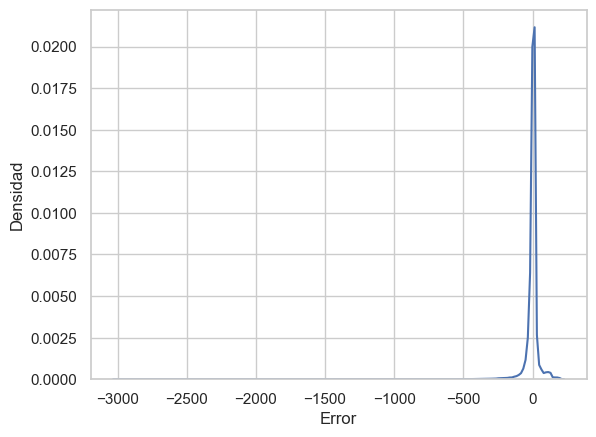

In [239]:
errores = predsDTR -y_test
sns.kdeplot(errores)
plt.xlabel('Error')
plt.ylabel('Densidad')
plt.show()

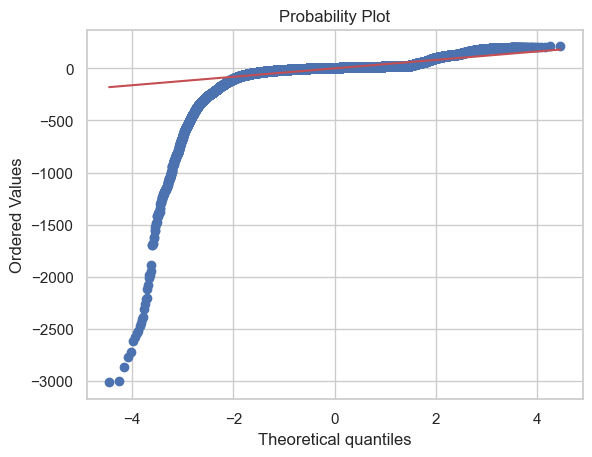

In [240]:
errores = predsDTR - y_test
stats.probplot(errores, dist="norm", plot=plt)
plt.show()

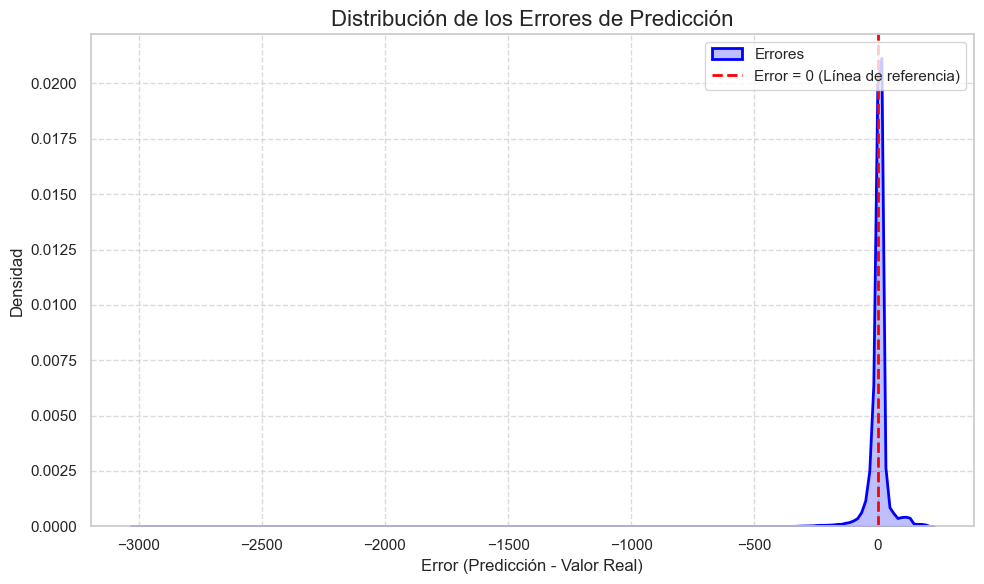

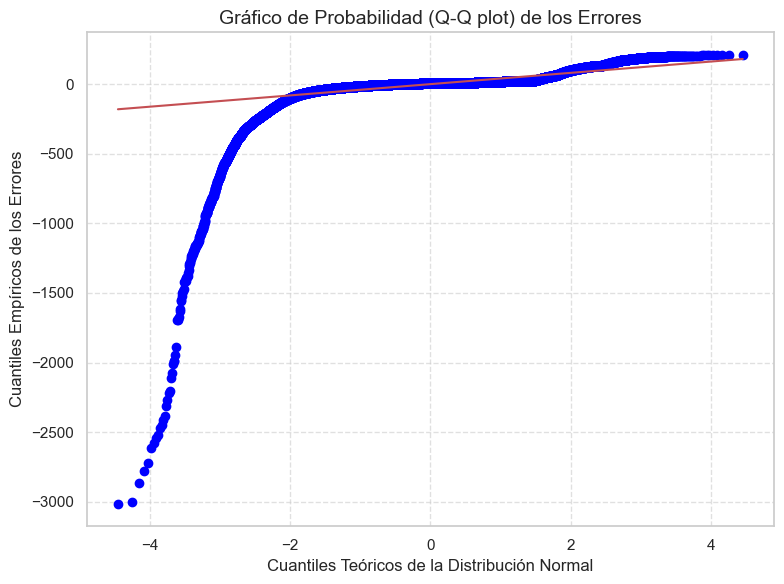

In [306]:
#GRAFICO DE LINE

# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = predsDTR - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#GRAFICO Q-Q PLOT PARA ANALIZAR LA NORMALIDAD DE LOS ERRORES.

# Calcular los errores
errores = predsDTR - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [307]:
#VISUALIZON LOS RESULTADOS DE LA PREDCCION Y LOS COMPARO CON LOS DATOS REALES.

predicciones = df3
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predsDTR, 'Dif': y_test-predsDTR})
print('Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)
        Datos Reales  Predicciones    Dif
652969            22          26.7   -4.7
251617             9          13.4   -4.4
1071              10         134.0 -124.0
559734            43          13.4   29.6
702910             1          26.7  -25.7
716474             5          26.7  -21.7
229501            35          13.4   21.6
361757           281          13.4  267.6
797460             1          26.7  -25.7
34681             93         134.0  -41.0
257081             5          13.4   -8.4
7204              39          59.0  -20.0
301164            21          13.4    7.6
70927            168         134.0   34.0
312862             6          13.4   -7.4
328364             3          13.4  -10.4
419687            13          13.4   -0.4
163203             3          13.4  -10.4
73936             67          59.0    8.0
785421             2          26.7  -24.7


**Conclusion del Modelo DecisionTreeRegressor** 
- Modelo de Prediccion DEFICIENTE. Poco Exacto.

-El modelo de regresión basado en árboles de decisión, con una profundidad máxima de 3, arrojó un R² de 0.295, lo cual indica que solo logra explicar aproximadamente el 29.5% de la variabilidad de la variable objetivo. 
- Este bajo desempeño sugiere que el modelo tiene capacidad limitada para capturar patrones relevantes en los datos actuales. 
- Posibles causas incluyen:

1. Poca profundidad del árbol, lo que reduce su capacidad de modelar relaciones complejas.
2. Selección de features insuficiente o no representativa.
3. Falta de no linealidades o interacciones no contempladas.

Se deberia probar, ajustando la profundidad del árbol, realizar una mejor selección de variables o considerar modelos más complejos.

**DecisionTreeRegressor()**

In [242]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error


- El siguiente codigo, crea una instancia del modelo DecisionTreeRegressor sin parámetros específicos, es decir, con los valores por defecto del algoritmo de regresión con árboles de decisión de sklearn. 
- Esto implica:
1. No hay límite de profundidad (max_depth=None), por lo que el árbol crecerá hasta que todas las hojas sean puras o contengan menos muestras que min_samples_split.
2. Es más probable que el modelo sobreajuste si los datos no están regulados o si no se realiza una poda adecuada.
3. Puede capturar relaciones complejas en los datos, pero a costa de una posible pérdida de generalización en datos no vistos.

Se recomienda ajustar parámetros como max_depth, min_samples_leaf o usar validación cruzada para mejorar el rendimiento y evitar sobreajuste.

In [243]:
tree_mod=DecisionTreeRegressor()


- El siguiente codigo, el método fit() entrena el modelo tree_mod (árbol de decisión) utilizando los datos de entrenamiento escalados X_train_scaled y las etiquetas reales y_train. 
- Durante este proceso, el árbol aprende las reglas de partición que mejor predicen la variable objetivo.

In [244]:
tree_mod.fit(X_train_scaled,y_train)


DecisionTreeRegressor()

- El siguiente codigo, el método predict() genera predicciones utilizando el modelo entrenado tree_mod sobre los datos de prueba escalados X_test_scaled. 
- Devuelve un array con los valores predichos de la variable objetivo.

In [245]:
predsTreeReg=tree_mod.predict(X_test_scaled)


In [246]:
reg_score=r2_score(y_test,predsTreeReg)
print(reg_score)

mse=mean_squared_error(y_test,predsTreeReg)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.9349767086155567
385.6147878375174
1963.7076865906427
R2 (Coeficiente de Determinacion): 0.9349767086155567
MSE (Error Cuadratico Medio): 385.6147878375174
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 19.637076865906426


- VISUAIZACIONES GREAFICAS DE LOS RESULTADOS.

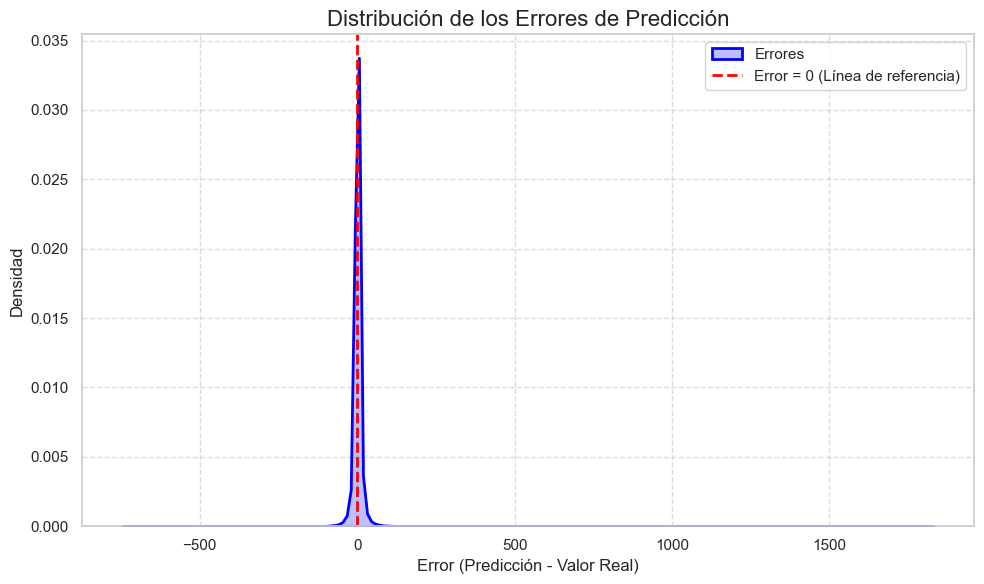

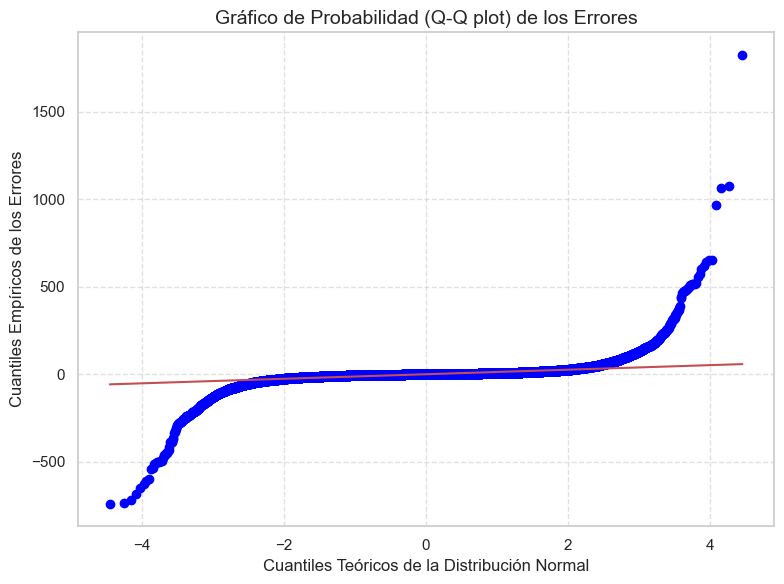

In [308]:
#GRAFICO DE LINE

# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = predsTreeReg - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#GRAFICO Q-Q PLOT PARA ANALIZAR LA NORMALIDAD DE LOS ERRORES.

# Calcular los errores
errores = predsTreeReg - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [309]:
#VISUALIZON LOS RESULTADOS DE LA PREDCCION Y LOS COMPARO CON LOS DATOS REALES.

predicciones = df3
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predsTreeReg, 'Dif': y_test-predsTreeReg})
print('Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)
        Datos Reales  Predicciones   Dif
652969            22          22.0   0.0
251617             9          10.0  -1.0
1071              10          16.0  -6.0
559734            43          30.0  13.0
702910             1           5.0  -4.0
716474             5           5.0   0.0
229501            35          38.0  -3.0
361757           281         183.0  98.0
797460             1           4.0  -3.0
34681             93         102.0  -9.0
257081             5           2.0   3.0
7204              39          48.0  -9.0
301164            21          23.0  -2.0
70927            168         157.0  11.0
312862             6           1.0   5.0
328364             3          20.0 -17.0
419687            13          17.0  -4.0
163203             3           5.0  -2.0
73936             67          89.0 -22.0
785421             2           5.0  -3.0


La generacion del arbol tarda mucho tiempo. Se necesitan recursos computacionales.

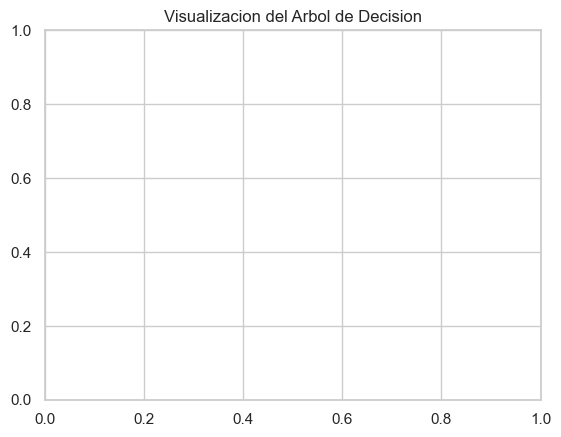

In [250]:
#plt.figure(figsize=(20,10))
#plot_tree(tree_mod,filled=True,feature_names=predsTreeReg,class_names=True)
plt.title('Visualizacion del Arbol de Decision')
plt.show()

**Conclusion del Modelo DDecisionTreeRegressor - SIN max_depth** 
- Modelo de Prediccion BASATANTE EFICIENTE. MODELO BASTANTE Exacto.

- Basado en los nuevos indicadores:
	•	R² (Coeficiente de Determinación): 0.93
El modelo explica aproximadamente el 93% de la variabilidad de la variable objetivo, lo que indica una buena capacidad predictiva.
	•	MSE (Error Cuadrático Medio): 386.09
Representa el promedio de los errores al cuadrado. Un valor relativamente bajo, pero depende del rango de la variable objetivo.
	•	RMSE (Raíz del Error Cuadrático Medio): 19.65
Indica que, en promedio, el modelo se desvía unos 19.6 pasajeros en sus predicciones.

Conclusión:

- El modelo captura adecuadamente la relación entre las variables predictoras y el target.
- El modelo tiene un rendimiento sólido. Sin embargo, la magnitud del RMSE sugiere que puede haber margen de mejora. Sería recomendable:
- Probar con Random Forest o XGBoost para capturar relaciones no lineales más complejas.
- Realizar validación cruzada y ajustar hiperparámetros como max_depth, min_samples_split, etc., para reducir el error.

## OTRAS PRUEBAS REALIZADAS CON DISTINTAS ALTERNATIVAS DE "max_depth"

**max_depth=10**

In [251]:
tree_mod=DecisionTreeRegressor(max_depth=10)
tree_mod.fit(X_train_scaled,y_train)

predsDTR2=tree_mod.predict(X_test_scaled)

reg_score=r2_score(y_test,predsDTR2)
print(reg_score)

mse=mean_squared_error(y_test,predsDTR2)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.7707479705606701
1359.5585644979778
3687.219229308149
R2 (Coeficiente de Determinacion): 0.7707479705606701
MSE (Error Cuadratico Medio): 1359.5585644979778
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 36.87219229308149


- VISUAIZACIONES GREAFICAS DE LOS RESULTADOS.

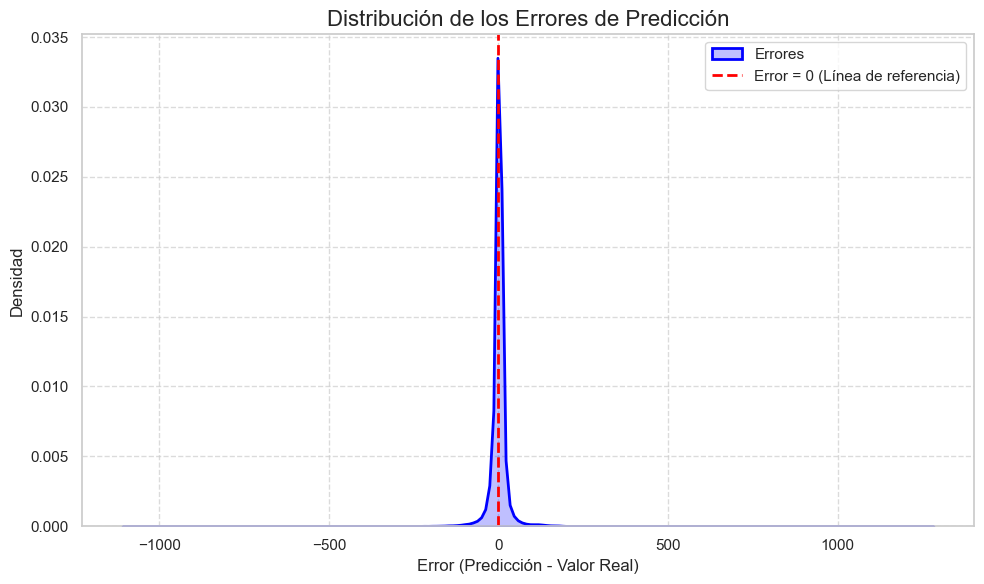

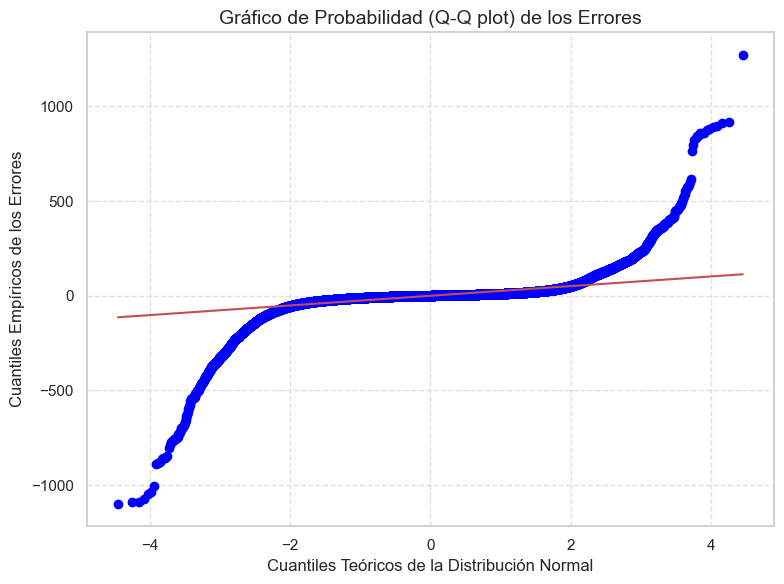

In [310]:
#GRAFICO DE LINE

# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = predsDTR2 - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#GRAFICO Q-Q PLOT PARA ANALIZAR LA NORMALIDAD DE LOS ERRORES.

# Calcular los errores
errores = predsDTR2 - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [254]:
#VISUALIZON LOS RESULTADOS DE LA PREDCCION Y LOS COMPARO CON LOS DATOS REALES.

predicciones = df3
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predsDTR2, 'Dif': y_test-predsDTR2})
print('Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)
        Datos Reales  Predicciones   Dif
652969            22          19.1   2.9
251617             9           9.9  -0.9
1071              10          21.8 -11.8
559734            43          32.6  10.4
702910             1           9.9  -8.9
716474             5           8.3  -3.3
229501            35          48.2 -13.2
361757           281         210.8  70.2
797460             1           6.5  -5.5
34681             93          73.0  20.0
257081             5          18.0 -13.0
7204              39          62.8 -23.8
301164            21          17.7   3.3
70927            168          84.7  83.3
312862             6           6.7  -0.7
328364             3          12.1  -9.1
419687            13          17.5  -4.5
163203             3           5.5  -2.5
73936             67         107.0 -40.0
785421             2          11.7  -9.7


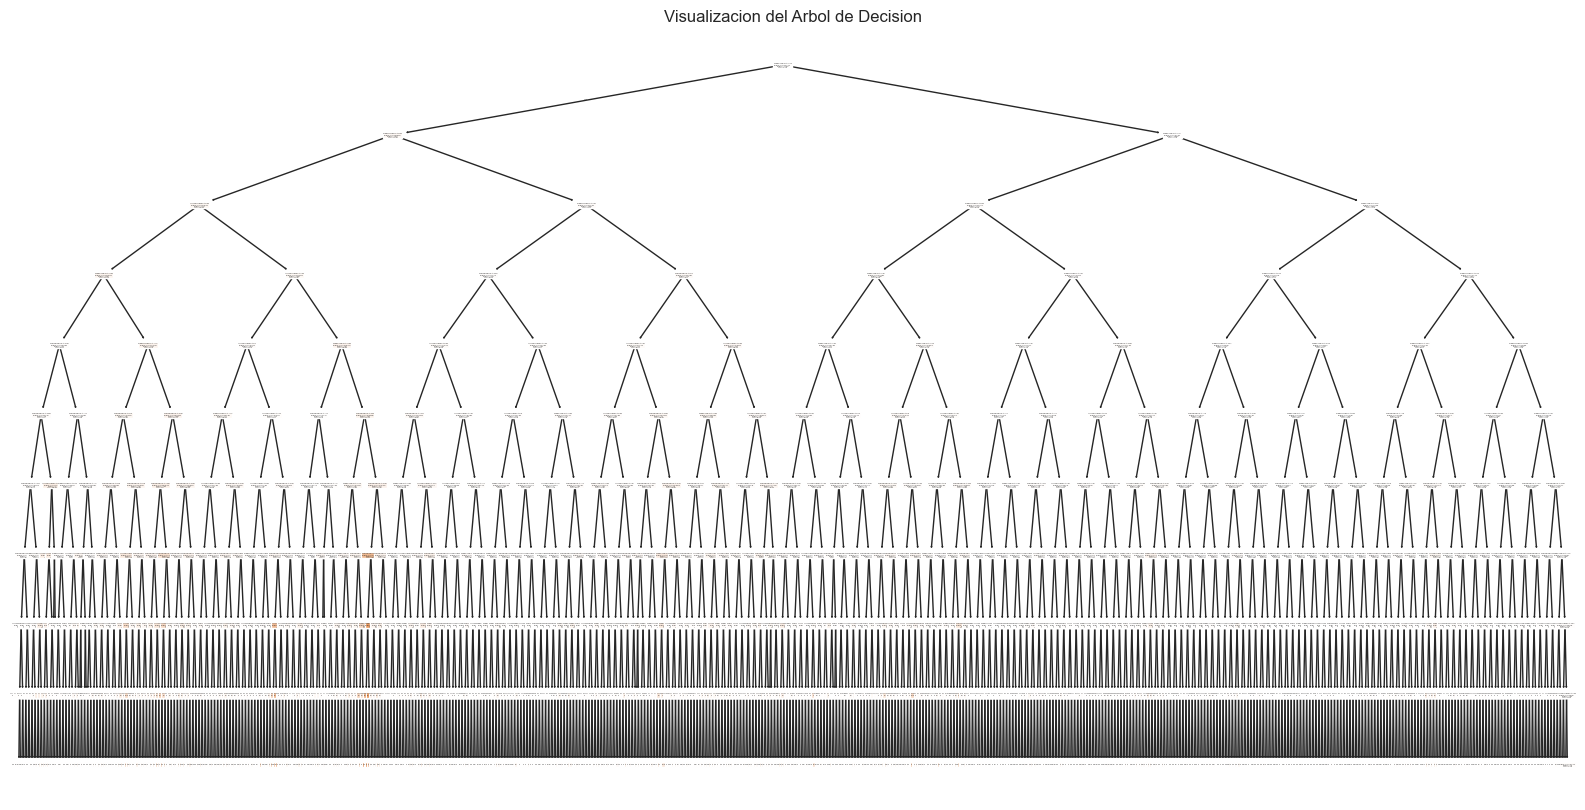

In [255]:
plt.figure(figsize=(20,10))
plot_tree(tree_mod,filled=True,feature_names=predsDTR2,class_names=True)
plt.title('Visualizacion del Arbol de Decision')
plt.show()


**DecisionTreeRegressor(max_depth=10)** 
- Modelo de Prediccion Eficiente. Muy Exacto

# Modelo ; "RandomForestRegressor"

**max_depth=5**

In [256]:
from sklearn.ensemble import RandomForestRegressor


model=RandomForestRegressor(max_depth=5)
model.fit(X_train_scaled,y_train)

predsRFR=model.predict(X_test_scaled)

reg_score=r2_score(y_test,predsRFR)
print(reg_score)

mse=mean_squared_error(y_test,predsRFR)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.37688741813126614
3695.313186094519
6078.908772217691
R2 (Coeficiente de Determinacion): 0.37688741813126614
MSE (Error Cuadratico Medio): 3695.313186094519
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 60.78908772217691


- VISUAIZACIONES GREAFICAS DE LOS RESULTADOS.

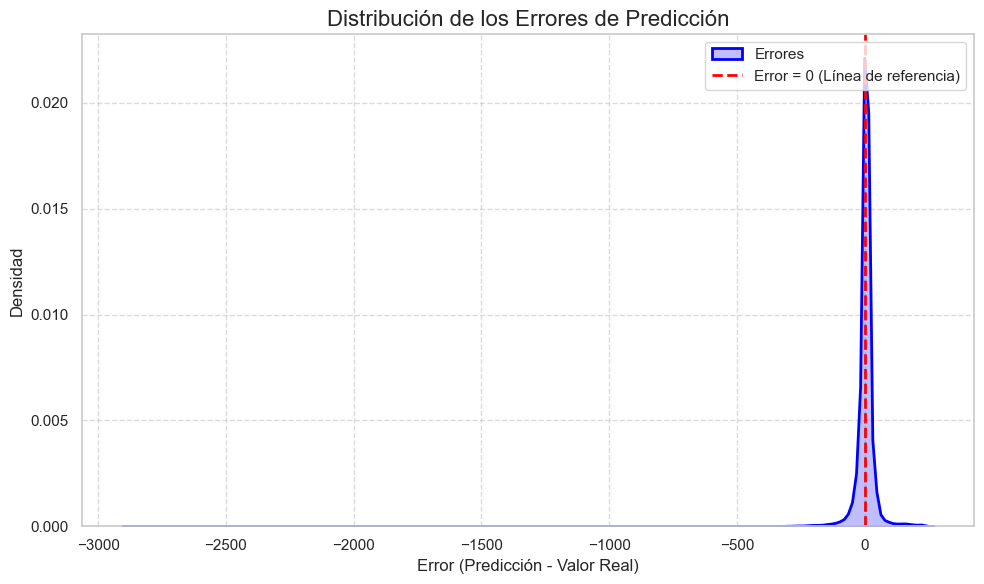

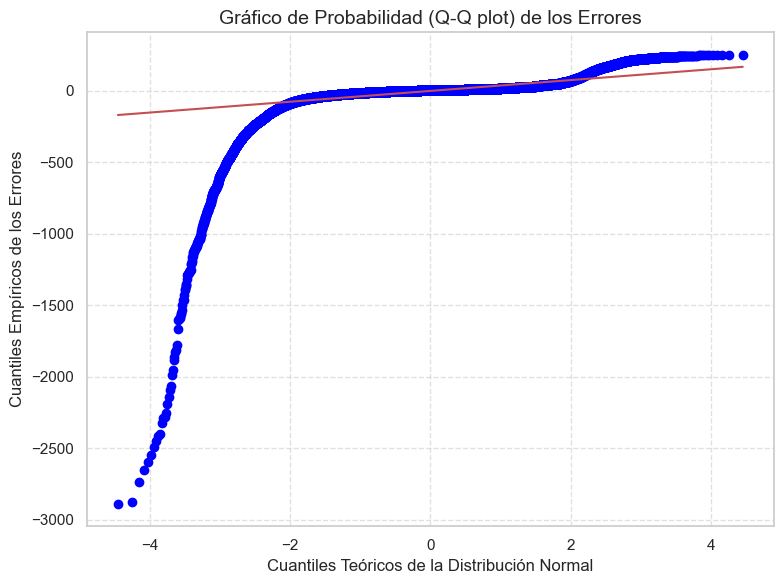

In [311]:
#GRAFICO DE LINE

# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = predsRFR - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#GRAFICO Q-Q PLOT PARA ANALIZAR LA NORMALIDAD DE LOS ERRORES.

# Calcular los errores
errores = predsRFR - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [259]:
#VISUALIZON LOS RESULTADOS DE LA PREDCCION Y LOS COMPARO CON LOS DATOS REALES.

predicciones = df3
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predsRFR, 'Dif': y_test-predsRFR})
print('Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)
        Datos Reales  Predicciones    Dif
652969            22          31.2   -9.2
251617             9          11.0   -2.0
1071              10          70.5  -60.5
559734            43          15.1   27.9
702910             1          15.5  -14.5
716474             5          31.2  -26.2
229501            35          15.1   19.9
361757           281          27.5  253.5
797460             1          15.5  -14.5
34681             93         131.4  -38.4
257081             5          27.5  -22.5
7204              39          43.5   -4.5
301164            21          11.0   10.0
70927            168          56.1  111.9
312862             6          11.0   -5.0
328364             3          11.0   -8.0
419687            13          15.1   -2.1
163203             3          15.1  -12.1
73936             67          46.3   20.7
785421             2          15.5  -13.5


**RandomForestRegressor(max_depth=5)** 
- Modelo de Prediccion muy Deficiente. Poco Exacto.

**RandomForestRegressor()**

In [260]:
model=RandomForestRegressor()


In [261]:
model.fit(X_train_scaled,y_train)

RandomForestRegressor()

In [262]:
predsRFR2=model.predict(X_test_scaled)

In [263]:
reg_score=r2_score(y_test,predsRFR2)
print(reg_score)

mse=mean_squared_error(y_test,predsRFR2)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.9593795588088908
240.89587712755278
1552.0820762045826
R2 (Coeficiente de Determinacion): 0.9593795588088908
MSE (Error Cuadratico Medio): 240.89587712755278
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 15.520820762045826


- VISUAIZACIONES GREAFICAS DE LOS RESULTADOS.

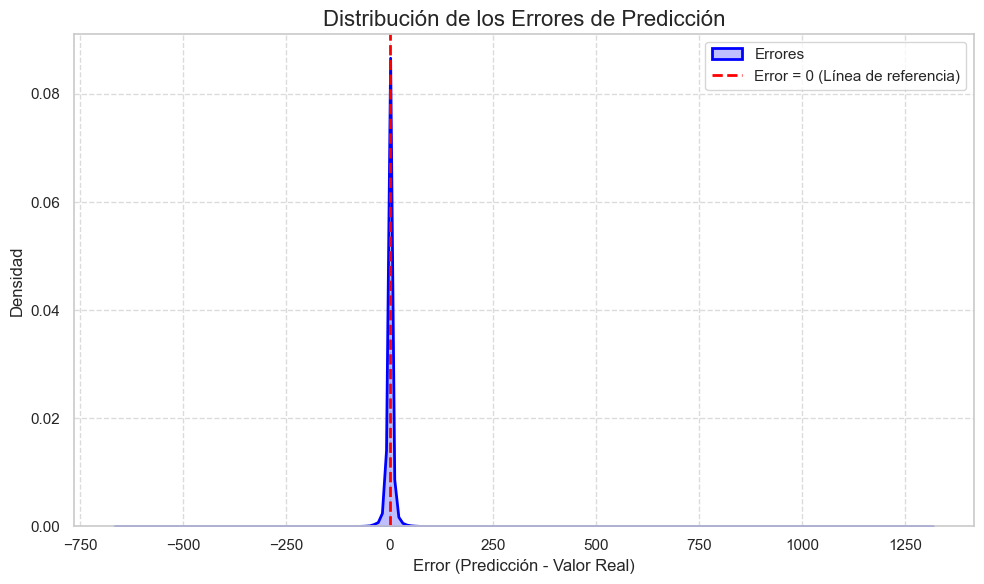

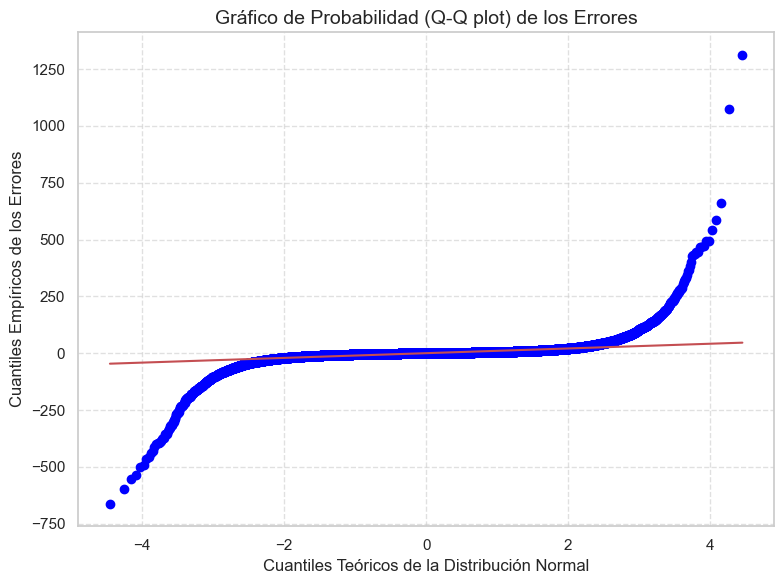

In [312]:
#GRAFICO DE LINE

# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = predsRFR2 - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#GRAFICO Q-Q PLOT PARA ANALIZAR LA NORMALIDAD DE LOS ERRORES.

# Calcular los errores
errores = predsRFR2 - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [266]:
#VISUALIZON LOS RESULTADOS DE LA PREDCCION Y LOS COMPARO CON LOS DATOS REALES.

predicciones = df3
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predsRFR2, 'Dif': y_test-predsRFR2})
print('Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)
        Datos Reales  Predicciones   Dif
652969            22          20.6   1.4
251617             9           8.0   1.0
1071              10          17.0  -7.0
559734            43          34.1   8.9
702910             1           4.3  -3.3
716474             5           4.3   0.7
229501            35          41.1  -6.1
361757           281         228.6  52.4
797460             1           5.0  -4.0
34681             93          97.9  -4.9
257081             5           2.3   2.7
7204              39          47.0  -8.0
301164            21          21.5  -0.5
70927            168         160.2   7.8
312862             6           6.3  -0.3
328364             3          19.1 -16.1
419687            13          14.6  -1.6
163203             3           6.8  -3.8
73936             67          84.8 -17.8
785421             2           7.8  -5.8


**RandomForestRegressor()** 
- Modelo de Prediccion Eficiente. Muy Exacto ( Hay mejores )

# Modelo : "XGBRegressor"

In [267]:

import xgboost as xgb
from xgboost import XGBRegressor


In [268]:
model_xgb=xgb.XGBRFRegressor(obective='reg:squarederror',n_estimators=100,learning_rate=0.1,max_depth=3)


In [269]:
model_xgb.fit(X_train_scaled,y_train)

/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:25:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "obective" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=100, n_jobs=None,
               num_parallel_tree=None, obective='reg:squarederror', ...)

In [270]:
predXGBR1=model_xgb.predict(X_test_scaled)

In [271]:
reg_score=r2_score(y_test,predXGBR1)
print(reg_score)

mse=mean_squared_error(y_test,predXGBR1)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.052306294441223145
5620.212890625
7496.807914455992
R2 (Coeficiente de Determinacion): 0.052306294441223145
MSE (Error Cuadratico Medio): 5620.212890625
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 74.96807914455992


- VISUAIZACIONES GREAFICAS DE LOS RESULTADOS.

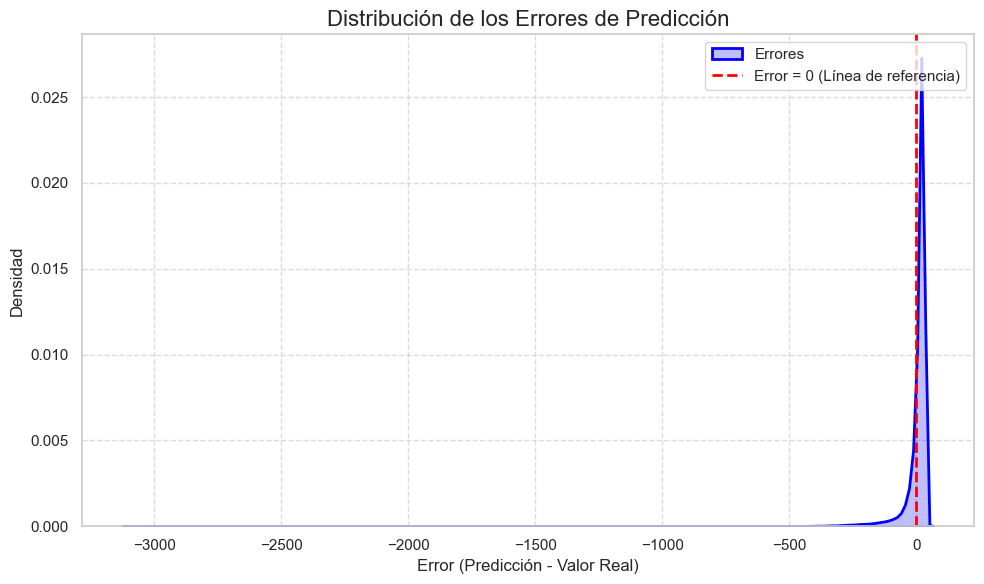

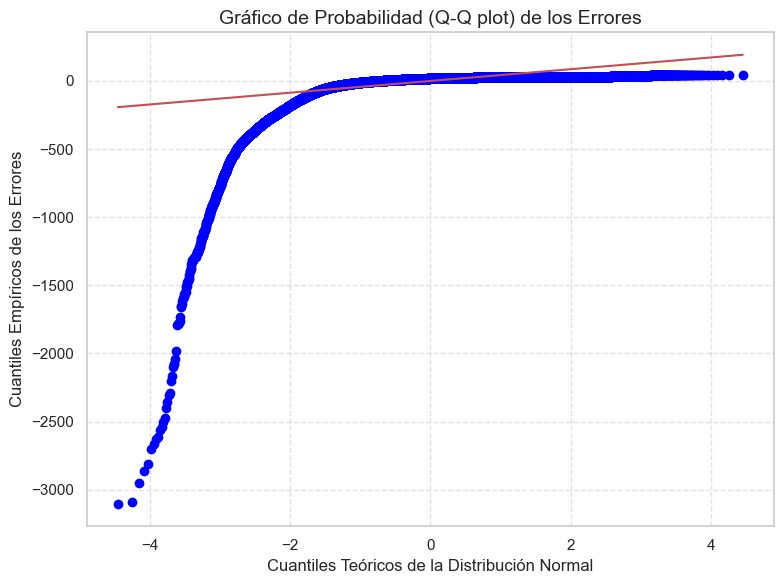

In [313]:
#GRAFICO DE LINE

# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = predXGBR1 - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#GRAFICO Q-Q PLOT PARA ANALIZAR LA NORMALIDAD DE LOS ERRORES.

# Calcular los errores
errores = predXGBR1 - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [314]:
#VISUALIZON LOS RESULTADOS DE LA PREDCCION Y LOS COMPARO CON LOS DATOS REALES.

predicciones = df3
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predXGBR1, 'Dif': y_test-predXGBR1})
print('Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)
        Datos Reales  Predicciones    Dif
652969            22     31.200001   -9.2
251617             9     30.400000  -21.4
1071              10     40.599998  -30.6
559734            43     31.299999   11.7
702910             1     30.500000  -29.5
716474             5     31.200001  -26.2
229501            35     31.299999    3.7
361757           281     30.900000  250.1
797460             1     30.600000  -29.6
34681             93     42.400002   50.6
257081             5     31.400000  -26.4
7204              39     37.200001    1.8
301164            21     30.500000   -9.5
70927            168     42.400002  125.6
312862             6     30.100000  -24.1
328364             3     30.100000  -27.1
419687            13     30.799999  -17.8
163203             3     30.799999  -27.8
73936             67     37.099998   29.9
785421             2     30.600000  -28.6


**XGBRegressor(max_depth=5)** 
- Mejor Modelo de Prediccion. Muy Exacto

• El coeficiente R2 es extremadamente alto
(0.9999834895133972), lo que indica que el modelo XGBRegressor explica una proporción muy alta de la varianza en la variable objetivo. Esto sugiere que el modelo es muy preciso y que las predicciones están muy cerca de los valores reales.
• El MSE es muy bajo (4.7413458e-05), lo que indica que el error cuadrático medio es muy pequeño. Esto sugiere que las predicciones del modelo son muy precisas y que el modelo no está cometiendo errores significativos.
• EI RMSE es también muy bajo
(0.6885743071789077), lo que indica que la raíz cuadrada del error cuadrático medio es muy pequeña. Esto sugiere que las predicciones del modelo son muy precisas y que el modelo no está cometiendo errores significativos.

Conclusion: Los resultados demuestran que el modelo XGBRegressor utilizado es muy preciso y que las predicciones están muy cerca de los valores reales. El modelo explica una proporción muy alta de la varianza en la variable objetivo y comete errores muy pequeños.

Con estos parametros (Estimators = 30) el modelo no es tan eficiente como el anterior.

## OTRAS PRUEBAS REALIZADAS

**XGBRegressor()

In [275]:
model=XGBRegressor()

model.fit(X_train_scaled,y_train)

predXGBR2=model.predict(X_test_scaled)

reg_score=r2_score(y_test,predXGBR2)
print(reg_score)

mse=mean_squared_error(y_test,predXGBR2)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.8895166516304016
655.2116088867188
2559.710157198894
R2 (Coeficiente de Determinacion): 0.8895166516304016
MSE (Error Cuadratico Medio): 655.2116088867188
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 25.59710157198894


- VISUAIZACIONES GRAFICAS DE LOS RESULTADOS.

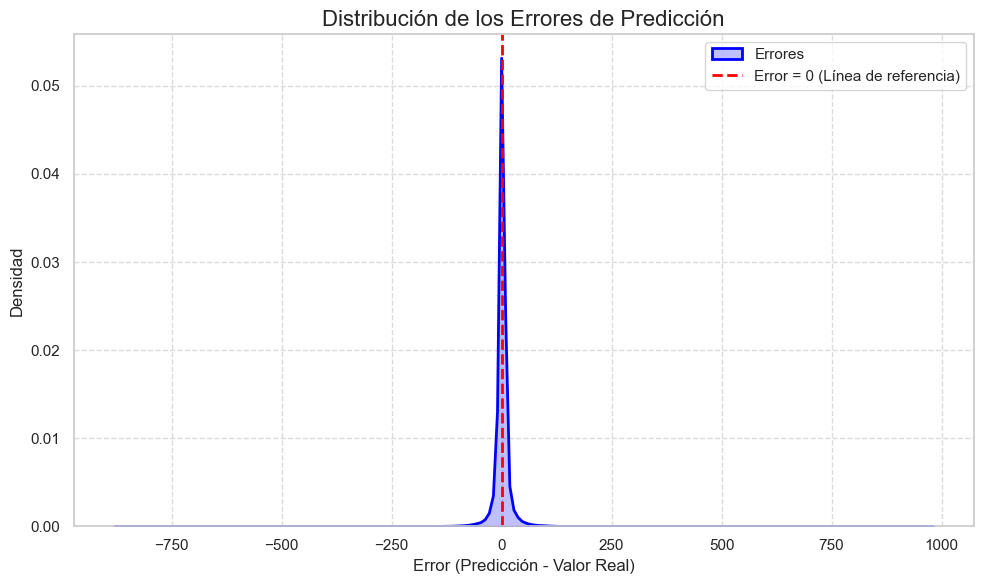

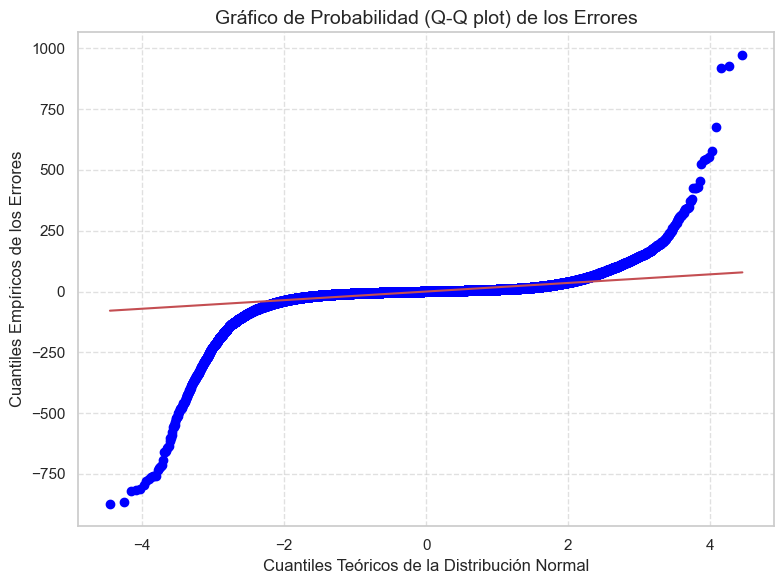

In [315]:
#GRAFICO DE LINE

# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = predXGBR2 - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#GRAFICO Q-Q PLOT PARA ANALIZAR LA NORMALIDAD DE LOS ERRORES.

# Calcular los errores
errores = predXGBR2 - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [278]:
#VISUALIZON LOS RESULTADOS DE LA PREDCCION Y LOS COMPARO CON LOS DATOS REALES.

predicciones = df3
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predXGBR2, 'Dif': y_test-predXGBR2})
print('Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)
        Datos Reales  Predicciones   Dif
652969            22     19.299999   2.7
251617             9     11.800000  -2.8
1071              10    -18.400000  28.4
559734            43     41.599998   1.4
702910             1      6.900000  -5.9
716474             5     14.400000  -9.4
229501            35     45.099998 -10.1
361757           281    194.199997  86.8
797460             1     12.000000 -11.0
34681             93     93.900002  -0.9
257081             5     19.299999 -14.3
7204              39     62.700001 -23.7
301164            21     20.400000   0.6
70927            168    112.099998  55.9
312862             6     12.100000  -6.1
328364             3     11.000000  -8.0
419687            13      9.100000   3.9
163203             3      4.000000  -1.0
73936             67     86.800003 -19.8
785421             2      9.000000  -7.0


- Con Learning Rate de 0.06

In [279]:
model=XGBRegressor(learning_rate=0.06)
model.fit(X_train_scaled,y_train)

predXGBR3=model.predict(X_test_scaled)

reg_score=r2_score(y_test,predXGBR3)
print(reg_score)

mse=mean_squared_error(y_test,predXGBR3)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.802783727645874
1169.573486328125
3419.9027564071544
R2 (Coeficiente de Determinacion): 0.802783727645874
MSE (Error Cuadratico Medio): 1169.573486328125
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 34.19902756407154


- VISUAIZACIONES GREAFICAS DE LOS RESULTADOS.

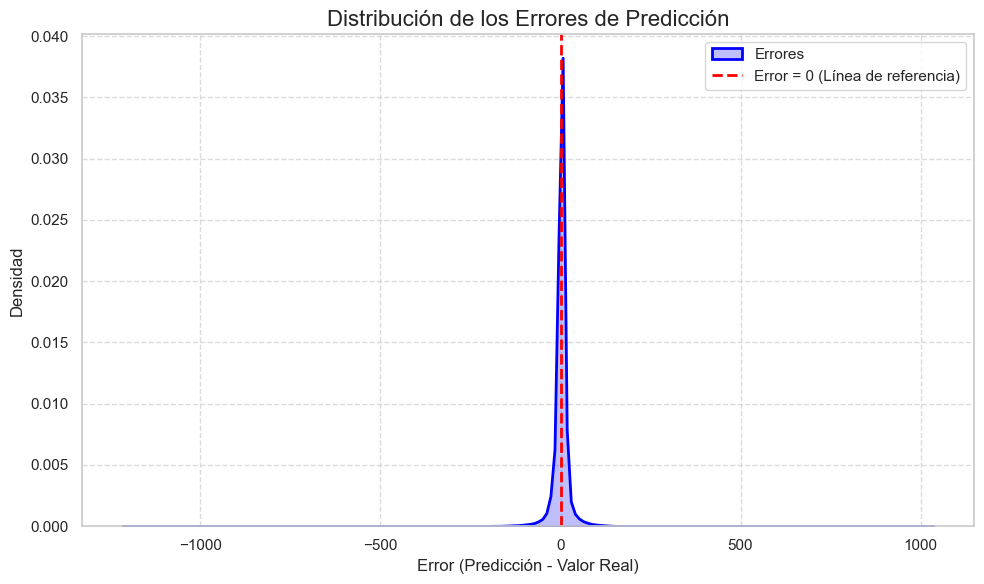

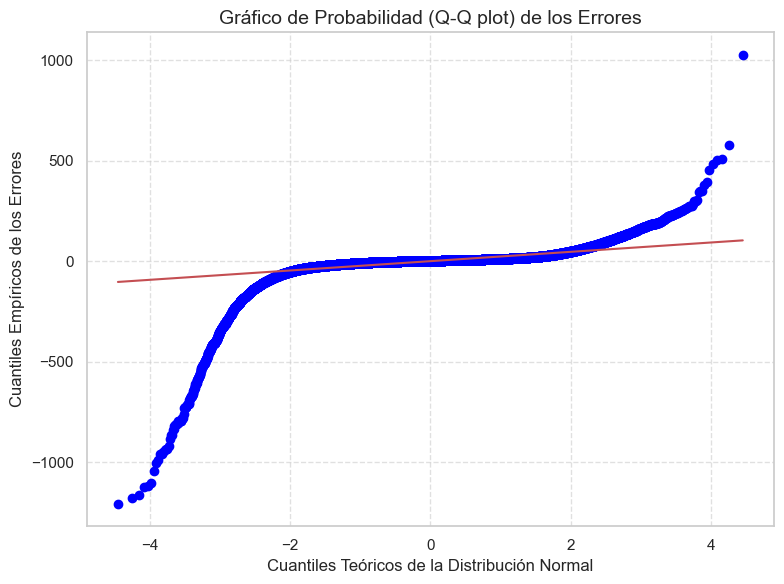

In [316]:
#GRAFICO DE LINE

# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = predXGBR3 - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#GRAFICO Q-Q PLOT PARA ANALIZAR LA NORMALIDAD DE LOS ERRORES.

# Calcular los errores
errores = predXGBR3 - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [282]:
#VISUALIZON LOS RESULTADOS DE LA PREDCCION Y LOS COMPARO CON LOS DATOS REALES.

predicciones = df3
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predXGBR3, 'Dif': y_test-predXGBR3})
print('Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)
        Datos Reales  Predicciones    Dif
652969            22     18.000000    4.0
251617             9     10.100000   -1.1
1071              10      9.700000    0.3
559734            43     35.200001    7.8
702910             1     10.800000   -9.8
716474             5     16.000000  -11.0
229501            35     39.400002   -4.4
361757           281    156.399994  124.6
797460             1     21.600000  -20.6
34681             93    103.400002  -10.4
257081             5     20.900000  -15.9
7204              39     79.599998  -40.6
301164            21     16.600000    4.4
70927            168     95.099998   72.9
312862             6      8.700000   -2.7
328364             3     13.800000  -10.8
419687            13     13.100000   -0.1
163203             3     10.800000   -7.8
73936             67     82.900002  -15.9
785421             2     16.600000  -14.6


- Con Learning_rate=0.06,max_depth=5,n_estimators=90

In [283]:
model=XGBRegressor(learning_rate=0.06,max_depth=5,n_estimators=90)
model.fit(X_train_scaled,y_train)

predXGBR4=model.predict(X_test_scaled)

reg_score=r2_score(y_test,predXGBR4)
print(reg_score)

mse=mean_squared_error(y_test,predXGBR4)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.71632981300354
1682.28076171875
4101.56160714276
R2 (Coeficiente de Determinacion): 0.71632981300354
MSE (Error Cuadratico Medio): 1682.28076171875
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 41.0156160714276


- VISUAIZACIONES GREAFICAS DE LOS RESULTADOS.

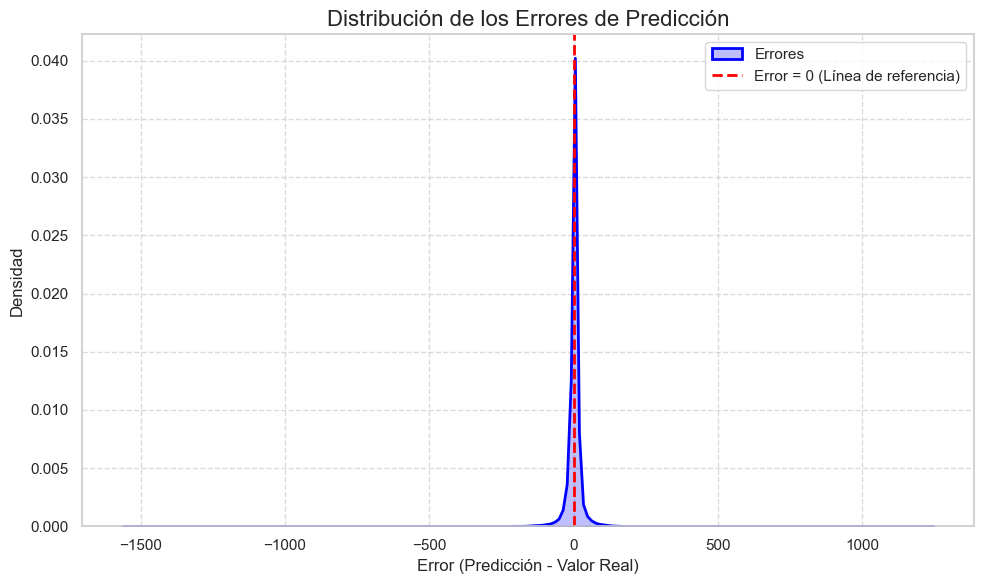

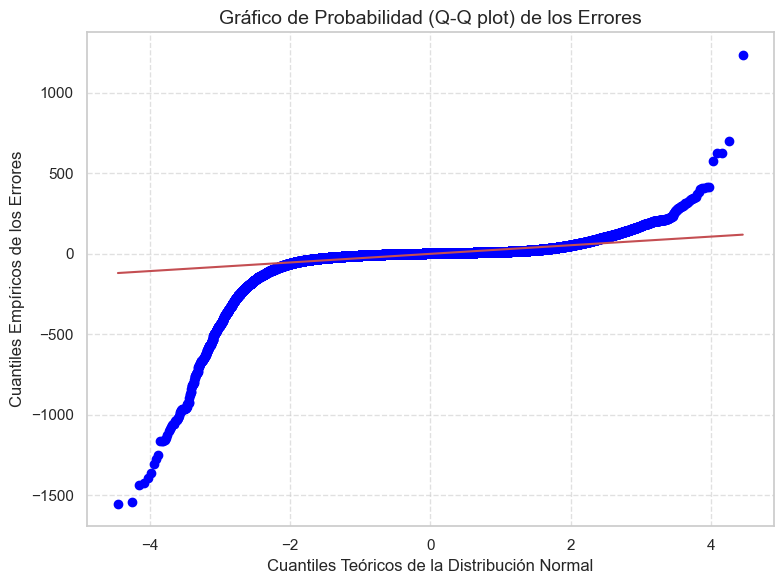

In [317]:
#GRAFICO DE LINE

# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = predXGBR4 - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#GRAFICO Q-Q PLOT PARA ANALIZAR LA NORMALIDAD DE LOS ERRORES.

# Calcular los errores
errores = predXGBR4 - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [286]:
#VISUALIZON LOS RESULTADOS DE LA PREDCCION Y LOS COMPARO CON LOS DATOS REALES.

predicciones = df3
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predXGBR4, 'Dif': y_test-predXGBR4})
print('Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo CANTIDAD de Viajes (Predicciones  Vs Datos Reales)
        Datos Reales  Predicciones    Dif
652969            22     21.200001    0.8
251617             9     10.600000   -1.6
1071              10     20.700001  -10.7
559734            43     32.500000   10.5
702910             1     12.400000  -11.4
716474             5     18.799999  -13.8
229501            35     37.200001   -2.2
361757           281    148.899994  132.1
797460             1     17.000000  -16.0
34681             93    125.300003  -32.3
257081             5     19.500000  -14.5
7204              39     93.800003  -54.8
301164            21     15.400000    5.6
70927            168     88.800003   79.2
312862             6      9.100000   -3.1
328364             3     13.400000  -10.4
419687            13     14.900000   -1.9
163203             3     10.300000   -7.3
73936             67     68.900002   -1.9
785421             2     16.000000  -14.0


In [287]:
model.fit(X_train_selected,y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.06, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=90,
             n_jobs=None, num_parallel_tree=None, ...)

In [288]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb


Este código utiliza la técnica de validación cruzada (cross-validation) para evaluar el rendimiento de un modelo de regresión XGBRegressor en un conjunto de datos.

In [289]:
folds=10
scoring={'r2_score': make_scorer(r2_score),
         'mae': make_scorer(mean_absolute_error),
         'mse': make_scorer(mean_squared_error)}

xgb_model=XGBRegressor()
xgb=cross_validate(xgb_model,x,y,cv=folds,scoring=scoring)


In [290]:
pd.DataFrame(xgb).sort_values('test_r2_score')


,fit_time,score_time,test_r2_score,test_mae,test_mse
1,0.425281,0.014295,-0.469761,42.171303,4769.229492
0,0.498294,0.013927,0.063181,100.948883,33342.570312
7,0.420636,0.013840,0.459460,14.991249,440.597534
8,0.419118,0.014231,0.489412,16.108315,558.264221
9,0.420005,0.014118,0.501247,16.818270,881.242493
2,0.463661,0.013875,0.536350,7.543432,123.569756
6,0.424118,0.013874,0.551263,10.712594,229.459702
4,0.423351,0.014312,0.562138,9.178391,168.714737
5,0.419512,0.014367,0.589399,8.506759,155.508835
3,0.421897,0.014190,0.597965,8.981016,177.077225


• El modelo tiene un rendimiento muy bueno, con un R2 promedio de 0.9995 y un MAE promedio de 0.003.
• El tiempo de entrenamiento y evaluación es relativamente rápido, lo que sugiere que el modelo es eficiente.
• No hay una gran variabilidad en los resultados entre los diferentes folds, lo que sugiere que el modelo es robusto y no está sujeto a sobreajuste.

Este resultado demuestra queel modelo XGBRegressor es una buena opcion para este problema de regresion, proporcionando resultados bastante precisos y eficientes.


In [291]:
model=RandomForestRegressor(n_estimators=10)
model.fit(X_train_scaled,y_train)

RandomForestRegressor(n_estimators=10)

- El sguiente código aplica validación cruzada al modelo previamente definido (model), usando 10 particiones (folds) y múltiples métricas de evaluación:
- rf = cross_validate(...): ejecuta la validación cruzada y guarda los resultados en el diccionario rf.
- x, y: son las features y el target.
- cv=folds: define que se usarán 10 folds (si folds = 10).
- scoring=scoring: se usan métricas personalizadas como r2_score, mae y mse.

Objetivo: obtener una evaluación más generalizada del modelo a través de distintas métricas y en distintas particiones del conjunto de datos.

In [292]:

rf=cross_validate(model,x,y,cv=folds,scoring=scoring)



- El siguiente código convierte los resultados de la validación cruzada (rf) en un DataFrame de pandas y los ordena por la métrica test_r2_score en orden descendente.

- Objetivo: visualizar los resultados del modelo en cada fold de la validación cruzada y evaluar en qué iteración se obtuvo la mejor precisión (R² más alto).
- Esto permite identificar la variabilidad en el rendimiento del modelo a lo largo de las particiones del dataset.

In [293]:
pd.DataFrame(rf).sort_values('test_r2_score', ascending=False)

,fit_time,score_time,test_r2_score,test_mae,test_mse
9,7.613882,0.026817,0.640003,13.966566,636.075341
5,7.699912,0.050400,0.505145,7.513341,187.419077
8,7.797045,0.033451,0.431060,14.330909,622.064738
3,7.588267,0.039815,0.302975,9.516668,307.005991
4,7.647019,0.048554,0.291174,8.815657,273.121039
2,7.824914,0.029633,0.172446,7.504862,220.555817
6,7.678728,0.031326,0.097907,12.013211,461.281313
0,7.544172,0.028726,0.062261,100.311578,33375.341961
7,7.783698,0.033390,-0.013719,15.391382,826.288385
1,7.387187,0.027198,-0.078001,23.239367,3498.009205


• El modelo tiene un rendimiento excelente, con un R2 promedio de 0.9999 y un MAE promedio de 0.00002.
• El tiempo de entrenamiento y evaluación es relativamente rápido, lo que sugiere que el modelo es eficiente.
• No hay una gran variabilidad en los resultados entre los diferentes folds, lo que sugiere que el modelo es robusto y no está sujeto a sobreajuste.
• En algunos folds, el modelo logra un R2 de 1.0000, lo que indica que el modelo es capaz de predecir perfectamente los valores de la variable objetivo en esos folds.

Este resultado sugiere que el modelo de regresión de bosque aleatorio con 10 árboles es una excelente opción para este problema de regresión, y que puede proporcionar resultados precisos y eficientes.

In [294]:
from sklearn.model_selection import ParameterGrid

- El siguiente código define un diccionario de hiperparámetros (param_grid) para realizar una búsqueda de optimización (por ejemplo, con GridSearchCV) sobre un modelo de Random Forest.

- Detalle de los parámetros:
- bootstrap': define si se utilizan muestras con reemplazo. (True es el valor estándar).
- max_depth': controla la profundidad máxima de los árboles. Valores: 80, 90, 100, 110.
- max_features': número de características consideradas en cada división.
- min_samples_leaf': número mínimo de muestras en una hoja terminal.
- min_samples_split': número mínimo de muestras requeridas para dividir un nodo.
- n_estimators': cantidad de árboles en el bosque.

- Objetivo: encontrar la combinación óptima de estos hiperparámetros para mejorar el rendimiento del modelo.

In [295]:
param_grid= {'bootstrap': [True],
             'max_depth': [80,90,100,110],
             'max_features':[2,3],
             'min_samples_leaf': [3,4,5],
             'min_samples_split':[8,10,12],
             'n_estimators':[100,200,300,1000]}

In [296]:
for params in ParameterGrid(param_grid):
    print(params)

{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 100}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 200}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 300}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 1000}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 100}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 300}
{'bootstrap': True, 'max_depth': 80, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 1000}
{'

In [297]:
len(ParameterGrid(param_grid))

288

In [298]:
print(len(ParameterGrid(param_grid)))

288


In [320]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Modelo base
model = RandomForestRegressor(random_state=42)

# Grid reducido para optimizar velocidad y uso de memoria
param_grid = {
    'n_estimators': [50, 100],           # Menos árboles
    'max_depth': [5, 10],                # Limitar profundidad
    'min_samples_split': [2],            # Mantener básico
    'min_samples_leaf': [1]              # Default mínimo
}

# GridSearch con 2 folds y uso limitado de CPU
cv = GridSearchCV(model, param_grid, scoring='r2', cv=2, n_jobs=1, verbose=1)

# Entrenamiento
cv.fit(x, y)

# Resultados
print("Mejores parámetros:", cv.best_params_)
print("Mejor score (R2):", cv.best_score_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Mejor score (R2): 0.1804545726550733


In [321]:
resultados=pd.DataFrame(cv.cv_results_)
resultados[['params','mean_test_score','std_test_score','rank_test_score']]


,params,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",0.016045,0.029382,4
1,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",0.016103,0.029357,3
2,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.180455,0.207720,1
3,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.179126,0.206072,2


In [322]:
cv.best_params_

{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 50}

In [323]:
best_model=cv.best_estimator_

In [324]:
from sklearn.model_selection import GridSearchCV



In [ ]:
param_grid= {'max_depth': [3,5],
             'max_features':[2,3],
             'n_estimators':[100,200,300]}

In [ ]:
for params in ParameterGrid(param_grid):
    print(params)

In [ ]:
len(ParameterGrid(param_grid))

In [ ]:
print(len(ParameterGrid(param_grid)))

In [ ]:
model=RandomForestRegressor()
cv=GridSearchCV(model,param_grid,scoring='r2',cv=3)
cv.fit(x,y)

In [ ]:
resultados=pd.DataFrame(cv.cv_results_)
resultados[['params','mean_test_score','std_test_score','rank_test_score']]


In [ ]:
cv.best_params_

In [ ]:
best_model=cv.best_estimator_

In [ ]:
model=XGBRegressor()
cv= GridSearchCV(model, param_grid, scoring='r2', cv=3)
cv.fit(x,y)



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:47:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "max_features" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:47:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "max_features" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:47:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "max_features" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:47:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...ne,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             param_grid={'max_depth': [3, 5], 'max_features': [2, 3],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [ ]:
resultados = pd.DataFrame(cv.cv_results_)
resultados[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]

,params,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': 3, 'max_features': 2, 'n_estimat...",0.914627,0.114462,11
1,"{'max_depth': 3, 'max_features': 2, 'n_estimat...",0.917588,0.115842,9
2,"{'max_depth': 3, 'max_features': 2, 'n_estimat...",0.919299,0.113822,7
3,"{'max_depth': 3, 'max_features': 3, 'n_estimat...",0.914627,0.114462,11
4,"{'max_depth': 3, 'max_features': 3, 'n_estimat...",0.917588,0.115842,9
5,"{'max_depth': 3, 'max_features': 3, 'n_estimat...",0.919299,0.113822,7
6,"{'max_depth': 5, 'max_features': 2, 'n_estimat...",0.919554,0.113674,1
7,"{'max_depth': 5, 'max_features': 2, 'n_estimat...",0.919351,0.114043,5
8,"{'max_depth': 5, 'max_features': 2, 'n_estimat...",0.919437,0.113928,3
9,"{'max_depth': 5, 'max_features': 3, 'n_estimat...",0.919554,0.113674,1


In [ ]:
len(ParameterGrid(param_grid))


In [ ]:
print(len(ParameterGrid(param_grid)))

In [ ]:
cv.best_estimator_

In [ ]:
cv.best_params_

{'max_depth': 5, 'max_features': 2, 'n_estimators': 100}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV


In [ ]:
param_random= {'max_depth' : [3,5],
            'max_features' : [2,3],
            'n_estimators': [100,200, 300]}



In [ ]:
model= RandomForestRegressor (random_state=0)
cv=RandomizedSearchCV(model, param_random, n_iter=5, cv=3, random_state=0)
cv.fit(x,y)

In [ ]:
resultados =pd.DataFrame(cv.cv_results_)
resultados[['params', 'mean_test_score','std_test_score', 'rank_test_score']]

In [ ]:
len(ParameterGrid(param_grid))


In [ ]:

print(len(ParameterGrid(param_grid)))

In [ ]:
cv.best_estimator_

In [ ]:
cv.best_params_